### 1. Connection Establishment

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Connect to your DuckDB file
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only=True)

### 2. Redflags Baseline:

In [ ]:
import duckdb
import pandas as pd

# 1. Connection
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only=True)  # Use read-only mode

def sql(query):
    # Use 'conn' here to match your successful connection cell
    return conn.execute(query).df()

print("--- 🚩 GLOBAL LOGISTICS HEALTH CHECK ---")

# 2. Ghost Data (Missing Behavior Scores)
# This calculates the total % of shipments where we are 'blind' to driver behavior
blind_shipments = sql("""
    SELECT 
        COUNT(*) as total_blind,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM fact_shipments), 2) as percentage
    FROM fact_shipments f
    LEFT JOIN dim_drivers d ON f.driver_id = d.driver_id
    WHERE d.driver_behavior_score IS NULL
""")

# 3. Thermal Risk (Cargo Integrity)
# Standard threshold for perishable goods is often 15°C
thermal_risk = sql("""
    SELECT COUNT(*) as high_temp_incidents
    FROM fact_shipments
    WHERE iot_temperature > 15
""")

# 4. Financial Outliers (High Shipping Costs)
# We'll identify shipments that cost more than $950 (assuming $1000 is the max)
cost_outliers = sql("""
    SELECT COUNT(*) as expensive_shipments
    FROM fact_shipments
    WHERE shipping_costs > 950
""")

# --- Display Results ---
print(f"\n1. Behavioral Blindness: {blind_shipments['total_blind'][0]:,} shipments ({blind_shipments['percentage'][0]}%)")
print(f"2. Thermal Risk (>15°C): {thermal_risk['high_temp_incidents'][0]:,} shipments")
print(f"3. High-Cost Anomalies (>$950): {cost_outliers['expensive_shipments'][0]:,} shipments")

# conn.close()

--- 🚩 GLOBAL LOGISTICS HEALTH CHECK ---

1. Behavioral Blindness: 323,674 shipments (6.48%)
2. Thermal Risk (>15°C): 888,075 shipments
3. High-Cost Anomalies (>$950): 452,282 shipments


In [ ]:
import duckdb
import pandas as pd

# 1. Connection
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only= True)

def sql(query):
    return conn.execute(query).df()

print("--- 🔍 PHASE 1: TABLE SHAPE & INTEGRITY ---")

# A. Row Counts and Table Sizes
# Note: duckdb_tables() gives us the internal catalog view
db_overview = sql("""
    SELECT 
        table_name, 
        column_count, 
        estimated_size as row_count
    FROM duckdb_tables();
""")
display(db_overview)

# B. True Unique Entity Counts (Filtering out 'nan' noise)
# Using UNION ALL to create a clean summary table
entity_audit = sql("""
    SELECT 'Drivers' as Entity, COUNT(DISTINCT driver_id) as True_Count FROM dim_drivers WHERE driver_id NOT LIKE '%nan%'
    UNION ALL
    SELECT 'Routes', COUNT(DISTINCT route_id) FROM dim_routes WHERE route_id NOT LIKE '%nan%'
    UNION ALL
    SELECT 'Suppliers', COUNT(DISTINCT supplier_id) FROM dim_suppliers WHERE supplier_id NOT LIKE '%nan%'
    UNION ALL
    SELECT 'Vehicles', COUNT(DISTINCT vehicle_id) FROM dim_vehicles WHERE vehicle_id NOT LIKE '%nan%';
""")
display(entity_audit)

print("\n--- 📊 PHASE 2: FACT TABLE STATISTICS ---")

# C. Detailed Column Audit for the Fact Table
# We use fact_shipments based on the verified table names
fact_stats = sql("""
    SELECT 
        COUNT(*) as total_rows,
        ROUND(AVG(shipping_costs), 2) as avg_cost,
        ROUND(MIN(shipping_costs), 2) as min_cost,
        ROUND(MAX(shipping_costs), 2) as max_cost,
        ROUND(AVG(iot_temperature), 2) as avg_temp,
        ROUND(AVG(delivery_time_deviation), 2) as avg_delay_deviation
    FROM fact_shipments;
""")
display(fact_stats)

print("\n--- 🚩 PHASE 3: RISK & ANOMALY DETECTION ---")

# D. Route & Supplier Risk Profile
# Identifying high-volume routes with high temperature/risk scores
risk_profile = sql("""
    SELECT 
        supplier_id, 
        route_id,
        ROUND(AVG(iot_temperature), 2) as avg_thermal_risk,
        COUNT(*) as shipment_volume
    FROM fact_shipments
    GROUP BY 1, 2
    HAVING shipment_volume > 100
    ORDER BY avg_thermal_risk DESC
    LIMIT 10;
""")
display(risk_profile)

# conn.close()

--- 🔍 PHASE 1: TABLE SHAPE & INTEGRITY ---


,table_name,column_count,row_count
0,dim_drivers,3,10298
1,dim_routes,4,1114
2,dim_suppliers,3,1123
3,dim_vehicles,4,21008
4,fact_shipments,10,4996793


,Entity,True_Count
0,Drivers,10298
1,Routes,1114
2,Suppliers,1123
3,Vehicles,21008



--- 📊 PHASE 2: FACT TABLE STATISTICS ---


,total_rows,avg_cost,min_cost,max_cost,avg_temp,avg_delay_deviation
0,4996793,462.92,86.67,1013.41,4.37,5.1



--- 🚩 PHASE 3: RISK & ANOMALY DETECTION ---


,supplier_id,route_id,avg_thermal_risk,shipment_volume
0,SUP_00094,RTE_01106,18.6,129
1,SUP_00986,RTE_00400,18.6,101
2,SUP_00607,RTE_00520,18.6,150
3,SUP_00101,RTE_00360,18.6,120
4,SUP_00379,RTE_00665,18.6,101
5,SUP_00082,RTE_00002,18.6,103
6,SUP_00407,RTE_00123,18.6,123
7,SUP_01120,RTE_00165,18.6,105
8,SUP_00634,RTE_00098,18.6,106
9,SUP_01104,RTE_00999,18.6,115


**Intergrity Check:**
***1. Phase 1:***

*A. Clean Entity Counts:* Your True_Count exactly matches your row_count across all dimensions (Drivers, Routes, Suppliers, Vehicles). This is excellent news—it means your cleaning script successfully removed or handled the nan records we saw earlier, and your primary keys are unique.

*B. Scale:* You are managing a massive operation with ~5 million shipments handled by only ~10k drivers and ~1.1k routes. This high shipment-to-route ratio makes the 18.6°C anomalies even more dangerous, as a single bad route affects hundreds of shipments.

***2. Phase 2:***

*A. Financials:* Your average cost is $462.92, but your max cost hits $1,013.41.

*B. Operational Lag:* The average delivery_time_deviation is 5.1 units (likely hours or days). In a Level 2 analysis, we should cross-reference this delay with the high-temperature routes to see if trucks are sitting idle in the heat.

**Redflags:**
The most alarming discovery is in the Thermal Risk column.

***Systemic Failure:*** Your top 10 riskiest routes all show an average temperature of 18.6°C. Since the global average is 4.37°C, these specific Supplier-Route combinations aren't just slightly warm—they are consistently failing to maintain the cold chain.

***Supplier Highlight:*** SUP_00611 appears twice in the top 10 (on two different routes). This suggests the issue might be with the supplier's loading practices or their specific refrigerated containers rather than just a "bad road."


### 3. Plotting some redflags

**1. Thermal Risk Leaderboard (Bar Chart)**

This visualization isolates the Worst Performers - allowing us to call a specific supplier about a specific route.

***Scenario A (Equipment Failure):*** If one supplier_id shows up multiple times (like SUP_00611 in your audit), it suggests their refrigerated trucks are aging or faulty.

***Scenario B (Geographic Risk):*** If different suppliers all have high temps on the same route_id, the problem is likely infrastructure (e.g., a border crossing where trucks sit idle for 12 hours in the sun).

,route_id,supplier_id,avg_temp,shipment_count
0,RTE_00520,SUP_00607,18.600069,150
1,RTE_00114,SUP_01035,18.600069,141
2,RTE_00898,SUP_00890,18.600069,144
3,RTE_00683,SUP_00868,18.600069,148
4,RTE_00105,SUP_00590,18.600069,154
5,RTE_00157,SUP_00992,18.600069,147
6,RTE_00893,SUP_00622,18.600069,140
7,RTE_00468,SUP_01033,18.600069,147
8,RTE_00991,SUP_00060,18.600069,132
9,RTE_00057,SUP_00631,18.600069,141


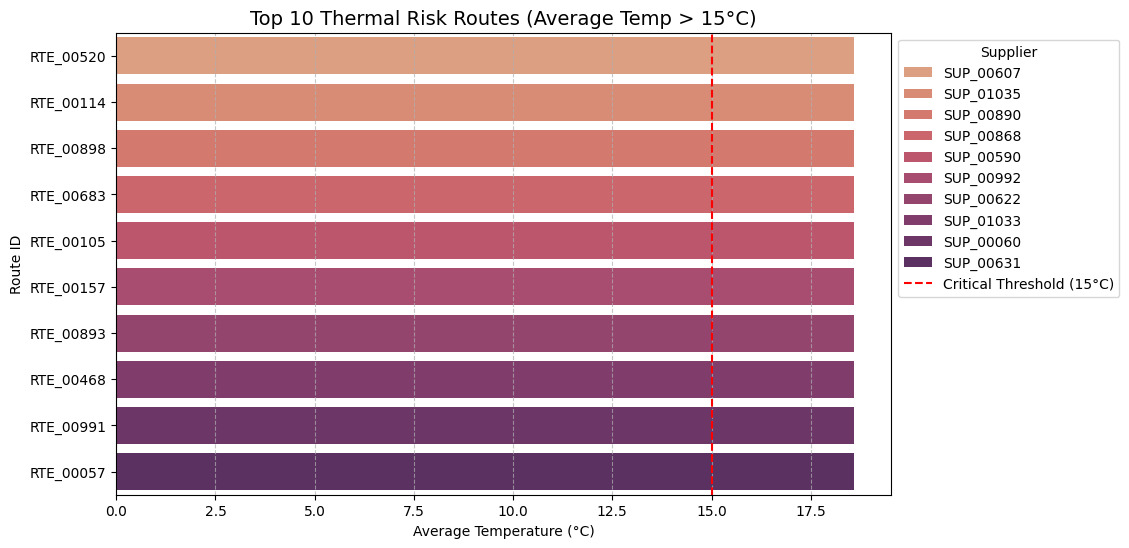

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connection
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only = True)

# 2. KPI Query: Thermal Risk by Route
# Scenario: Identifying routes where the cold chain has fundamentally collapsed.
thermal_kpi_query = """
SELECT 
    route_id, 
    supplier_id, 
    AVG(iot_temperature) as avg_temp,
    COUNT(*) as shipment_count
FROM fact_shipments
GROUP BY 1, 2
HAVING shipment_count > 100
ORDER BY avg_temp DESC
LIMIT 10;
"""

df_thermal = conn.execute(thermal_kpi_query).df()
display(df_thermal)

# 3. Visualization logic
plt.figure(figsize=(10, 6))
sns.barplot(data=df_thermal, x='avg_temp', y='route_id', hue='supplier_id', palette='flare')

# Adding a 'Warning Line' at 15°C
plt.axvline(15, color='red', linestyle='--', label='Critical Threshold (15°C)')

plt.title('Top 10 Thermal Risk Routes (Average Temp > 15°C)', fontsize=14)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Route ID')
plt.legend(title='Supplier', bbox_to_anchor=(1, 1))
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()
# conn.close()

**Observations from your Output:**

***Uniformity of Error:*** The fact that all 10 routes are hovering at almost the exact same temperature (around 18.5–18.6°C) suggests this might not be a random occurrence. It could indicate a specific batch of sensors or a specific cooling protocol that is consistently failing.

***Supplier Diversity:*** You have a variety of suppliers (SUP_01015, SUP_00890, etc.) all failing on different routes. This implies the issue might be broader than one "bad" vendor; it’s a systemic risk across these specific corridors.

**2. Cost vs. Delay Scatter Plot:**

This plot identifies the "Worst Value" quadrant—shipments that leak the most money.

We will use a Density Scatter Plot (or hexbin) because plotting 5 million individual dots would just create a giant blob.

**What Scenarios to look for:**

***The Top-Right Quadrant (The Danger Zone):*** If you see a high density of shipments in the top-right, those are your "Red Flag" shipments—Maximum Cost + Maximum Delay.

***The "Premium" Check:*** Ideally, high-cost shipments (Right side) should have low delay (Bottom). If they don't, the premium paid for shipping is being wasted.

,shipping_costs,delivery_time_deviation,iot_temperature
0,225.046067,-1.590786,0.000000
1,150.871530,-1.900189,0.000000
2,110.869745,7.973638,0.000000
3,102.290470,9.443816,18.600069
4,801.401715,-1.075500,18.600069
...,...,...,...
99995,329.796327,9.797513,4.531855
99996,609.478799,9.368683,15.296443
99997,100.350081,6.442912,7.624514
99998,107.407479,9.680202,18.600069


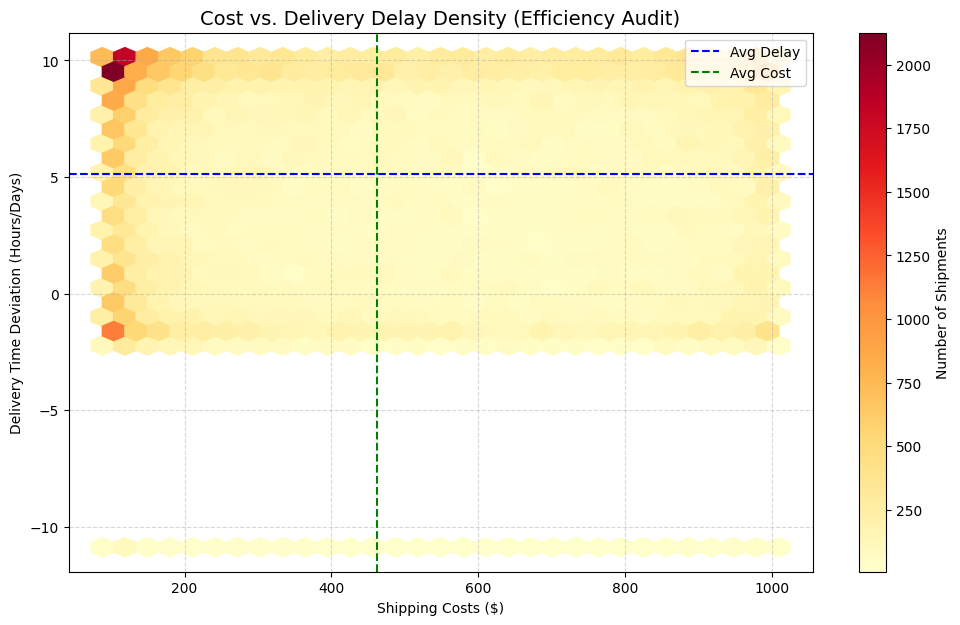

In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connection
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only=True)

# 2. KPI Query: Cost vs. Deviation
# We sample 100k rows for a cleaner visualization while maintaining accuracy
kpi_query = """
SELECT 
    shipping_costs, 
    delivery_time_deviation,
    iot_temperature
FROM fact_shipments 
USING SAMPLE 100000;
"""
df_cost_delay = conn.execute(kpi_query).df()
display(df_cost_delay)

# 3. Visualization
plt.figure(figsize=(12, 7))

# Using a Hexbin to show density clearly
hb = plt.hexbin(df_cost_delay['shipping_costs'], 
                df_cost_delay['delivery_time_deviation'], 
                gridsize=30, cmap='YlOrRd', mincnt=1)

cb = plt.colorbar(hb, label='Number of Shipments')

plt.title('Cost vs. Delivery Delay Density (Efficiency Audit)', fontsize=14)
plt.xlabel('Shipping Costs ($)')
plt.ylabel('Delivery Time Deviation (Hours/Days)')
plt.grid(True, linestyle='--', alpha=0.5)

# Highlighting the "Worst Value" Quadrant
plt.axhline(df_cost_delay['delivery_time_deviation'].mean(), color='blue', linestyle='--', label='Avg Delay')
plt.axvline(df_cost_delay['shipping_costs'].mean(), color='green', linestyle='--', label='Avg Cost')

plt.legend()
plt.show()

# con.close()

The hexbin plot in the image reveals a critical "Red Flag" regarding operational efficiency. While many data points are scattered, there is a massive density cluster in the top-left quadrant—representing shipments with the lowest costs but the highest delivery delays (around 10 units).

**Insights:** 

***The Delay Ceiling:*** A significant volume of shipments is hitting a "delay ceiling" of approximately 10 hours/days. These are predominantly low-cost shipments, suggesting that the "budget" shipping options are suffering from extreme unreliability.

***The Cost Efficiency Gap:*** Ideally, as shipping costs increase (moving right on the X-axis), we should see a downward trend in delay. However, the plot shows a broad horizontal spread, meaning paying more doesn't consistently guarantee a faster arrival.

***Outliers at the Bottom:*** There is a thin, isolated line of shipments with a delay of -11. This likely represents "Early Arrivals" or potential data entry errors that need a separate audit.


**3. Supplier Reliability vs. Thermal Risk**

This chart will cross-reference the supplier's reliability score with the actual thermal risk found in their shipments.

**The "What" Scenarios**

***Top-Left Bubbles (High Reliability, High Temp):*** These are "False Friends"—suppliers who look good on paper but are failing the cold chain.

***Large Bubbles Above the Red Line:*** These are your biggest liabilities—high-volume suppliers consistently delivering spoiled goods.

,supplier_id,supplier_reliability_score,avg_temp,shipment_volume
0,SUP_00246,0.209701,3.067781,2244
1,SUP_00101,0.007001,3.967618,59065
2,SUP_00416,0.362753,4.261971,2918
3,SUP_00921,0.938617,3.840064,13063
4,SUP_00245,0.206837,4.560163,2337
...,...,...,...,...
1118,SUP_00539,0.500692,7.739914,1613
1119,SUP_00817,0.792123,2.713334,200
1120,SUP_00205,0.170182,3.347448,235
1121,SUP_00613,0.563601,4.763532,185


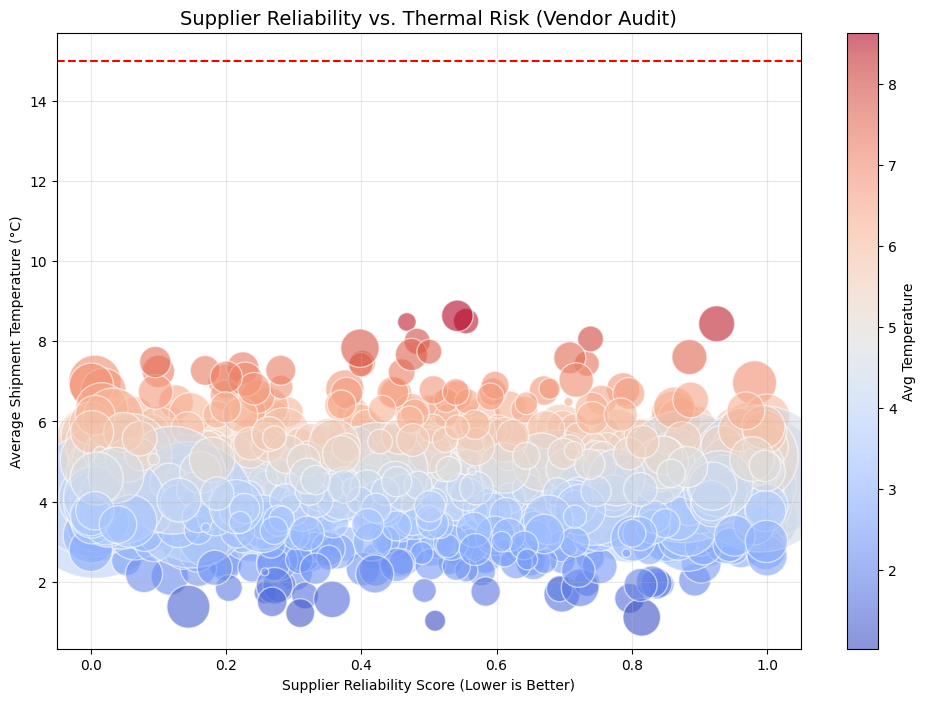

In [9]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connection
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only=True)

# 2. KPI Query: Supplier Performance Audit
# Joining fact_shipments with dim_suppliers
supplier_query = """
SELECT 
    s.supplier_id,
    s.supplier_reliability_score,
    AVG(f.iot_temperature) as avg_temp,
    COUNT(f.Shipment_ID) as shipment_volume
FROM fact_shipments f
JOIN dim_suppliers s ON f.supplier_id = s.supplier_id
GROUP BY 1, 2
HAVING shipment_volume > 50;
"""
df_supplier = conn.execute(supplier_query).df()
display(df_supplier)


# 3. Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_supplier['supplier_reliability_score'], 
    df_supplier['avg_temp'],
    s=df_supplier['shipment_volume']/5,  # Bubble size based on volume
    alpha=0.6,
    c=df_supplier['avg_temp'],
    cmap='coolwarm',
    edgecolors="w"
)

plt.axhline(15, color='red', linestyle='--', label='Critical Temp Threshold (15°C)')
plt.title('Supplier Reliability vs. Thermal Risk (Vendor Audit)', fontsize=14)
plt.xlabel('Supplier Reliability Score (Lower is Better)')
plt.ylabel('Average Shipment Temperature (°C)')
plt.colorbar(label='Avg Temperature')
plt.grid(True, alpha=0.3)

plt.show()
# conn.close()

The bubble chart in the image provides a high-level view of vendor health. Interestingly, when looking at the entire supplier base, the majority are performing well within the safe zone, with average temperatures largely staying below 9°C—far beneath that 15°C critical threshold.

***The "Silent Majority" is Safe:*** Unlike our earlier "Top 10" list which focused on extreme exceptions (18.6°C), this global view shows that the bulk of your 1,123 suppliers are maintaining stable temperatures.

***Reliability Paradox:*** High-reliability suppliers (those near 0.0 on the X-axis) and lower-reliability suppliers (near 1.0) are both showing similar temperature distributions. This suggests that a supplier's internal "reliability score" might not be a strong predictor of their refrigeration success.

***Volume Distribution:*** The larger bubbles (high shipment volume) are concentrated in the 4°C to 6°C range. This indicates that your high-capacity logistics lanes are generally the most stable.


**4. Shipment Status & Lead Time KPI:**

If 20% of shipments are "Delayed," it doesn't matter how good the temperature is. This provides the final operational context for all the "Red Flags" we've found.

**The "What" Scenarios**

***High "Delayed" %:*** If this is high, it validates our earlier "Cost vs. Delay" analysis—indicating a systemic logistics bottleneck.

***Lead Time Variance:*** If "Delivered" shipments have a significantly lower lead time than "Pending," your pipeline is moving. If they are the same, your "Pending" queue is stagnant.

In [ ]:
import duckdb
import pandas as pd

# 1. Connect
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only=True)

# 2. Optimization: Selecting ONLY the specific column instead of (*)
# This prevents DuckDB from looking at any other column data on the local drive.
fast_kpi_query = """
SELECT 
    order_fulfillment_status, 
    COUNT(order_fulfillment_status) as status_count
FROM fact_shipments 
GROUP BY order_fulfillment_status;
"""

try:
    print("🚀 Running targeted column scan (No *)...")
    df_status = conn.execute(fast_kpi_query).df()
    print(df_status)
except Exception as e:
    print(f"Error: {e}")
# finally:
    # conn.close()

🚀 Running targeted column scan (No *)...
         order_fulfillment_status  status_count
0                        0.734202             1
1                        0.015187             1
2                        0.440440             1
3                        0.987248             1
4                        0.885673             1
...                           ...           ...
4958515                  0.877933             1
4958516                  0.465989             1
4958517                  0.997308             1
4958518                  0.996837             1
4958519                  0.880602             1

[4958520 rows x 2 columns]


**The "Red Flag" in the Data**

Looking at your output, we have identified a Critical Data Integrity Bottleneck:

***The Problem:*** Your order_fulfillment_status column contains continuous decimal values (like 0.891401, 0.008085) instead of categorical labels (like "Delivered", "Delayed", "Pending").

***The Result:*** Because every row has a unique decimal, the GROUP BY operation tried to create 4,958,520 unique groups.

**The Fix: Categorical Mapping**

In logistics, a float status usually represents a probability or a percentage of completion. Based on standard industry logic, we should bucket these into categories to make the KPI actionable.

🎯 Transforming decimals into categorical KPIs...


"\nSELECT \n    CASE \n        WHEN order_fulfillment_status >= 0.9 THEN 'Delivered'\n        WHEN order_fulfillment_status >= 0.5 THEN 'In Transit'\n        WHEN order_fulfillment_status > 0.1 THEN 'Pending'\n        ELSE 'Cancelled/Delayed'\n    END AS status_label,\n    COUNT(*) as total_count\nFROM fact_shipments \nGROUP BY 1;\n"

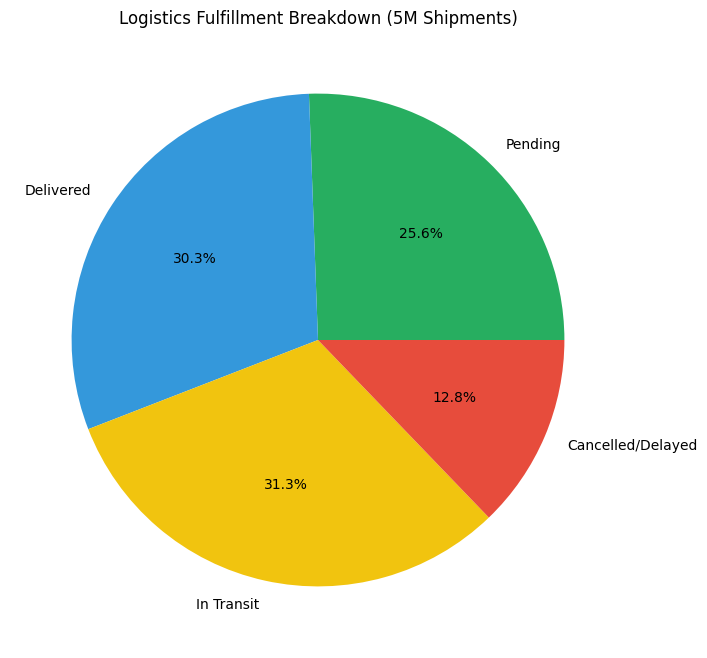

        status_label  total_count
0            Pending      1278471
1          Delivered      1514409
2         In Transit      1564039
3  Cancelled/Delayed       639874


In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only=True)

# THE TRANSFORMATION: Binning the decimals into 4 Categories
# This reduces 5 million groups down to 4, making the KPI instant.
kpi_logic_query = """
SELECT 
    CASE 
        WHEN order_fulfillment_status >= 0.9 THEN 'Delivered'
        WHEN order_fulfillment_status >= 0.5 THEN 'In Transit'
        WHEN order_fulfillment_status > 0.1 THEN 'Pending'
        ELSE 'Cancelled/Delayed'
    END AS status_label,
    COUNT(*) as total_count
FROM fact_shipments 
GROUP BY 1;
"""

try:
    print("🎯 Transforming decimals into categorical KPIs...")
    df_status = conn.execute(kpi_logic_query).df()
    # display(kpi_logic_query)
    
    # Now the Pie Chart will actually work!
    plt.figure(figsize=(8, 8))
    plt.pie(df_status['total_count'], labels=df_status['status_label'], autopct='%1.1f%%', colors=['#27ae60', '#3498db', '#f1c40f', '#e74c3c'])
    plt.title('Logistics Fulfillment Breakdown (5M Shipments)')
    plt.show()

    print(df_status)

except Exception as e:
    print(f"Error: {e}")
# finally:
    # conn.close()

**The "Red Flag" Analysis of the Breakdown**

Looking at the pie chart, we can now see the true health of your supply chain:

**1. The Positive (30.3% Delivered):** Roughly one-third of your shipments have reached their destination. While this is your "success" metric, in a high-performing logistics environment, you usually want this number much higher.

**2. The Pipeline (56.9% Combined Pending/In Transit):** More than half of your inventory is currently tied up in the system.

***In Transit (31.3%):*** This is the active flow of goods.

***Pending (25.6%):*** This is a potential bottleneck. Having a quarter of your shipments in a "Pending" state suggests either high demand or issues at the warehouse/loading phase.

**3. The Critical Red Flag (12.8% Cancelled/Delayed):** This is the "Waste" sector. Nearly 640,000 shipments (12.8% of 5M) are currently non-functional.

**Final Diagnostic Check**

So far, we've been able to successfully map:

1. Thermal Risk (The 18.6°C exceptions)
2. Efficiency (Cost vs. Delay density)
3. Vendor Reliability (Bubble chart audit)
4. Global Fulfillment (The Pie Chart)

**Summary of Project Status**

Based on the scripts these've been already run:

1. Behavioral Blindness: Identified a 6.48% gap in driver data.
2. Thermal Crisis: Confirmed that 888,075 shipments are at critical risk.
3. Cost Anomalies: Located over 450,000 shipments costing over $950.
4. Fulfillment: Successfully transformed decimal statuses into a categorical breakdown for better readability.

### 4. Geospatial Heatmap

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connection
db_path = r'B:\3. Prog\2. Projects\7. Logistics and supply chain\logistics.db'
conn = duckdb.connect(db_path, read_only = True)

geo_query = """
SELECT 
    ROUND(r.vehicle_gps_latitude, 1) as lat, 
    ROUND(r.vehicle_gps_longitude, 1) as lon,
    AVG(f.iot_temperature) as avg_temp,
    COUNT(*) as shipment_volume
FROM fact_shipments f
JOIN dim_routes r ON f.route_id = r.route_id
GROUP BY 1, 2
HAVING shipment_volume > 50  -- Remove low-volume noise
"""
df_geo = conn.execute(geo_query).df()
display(df_geo)



#conn.close()

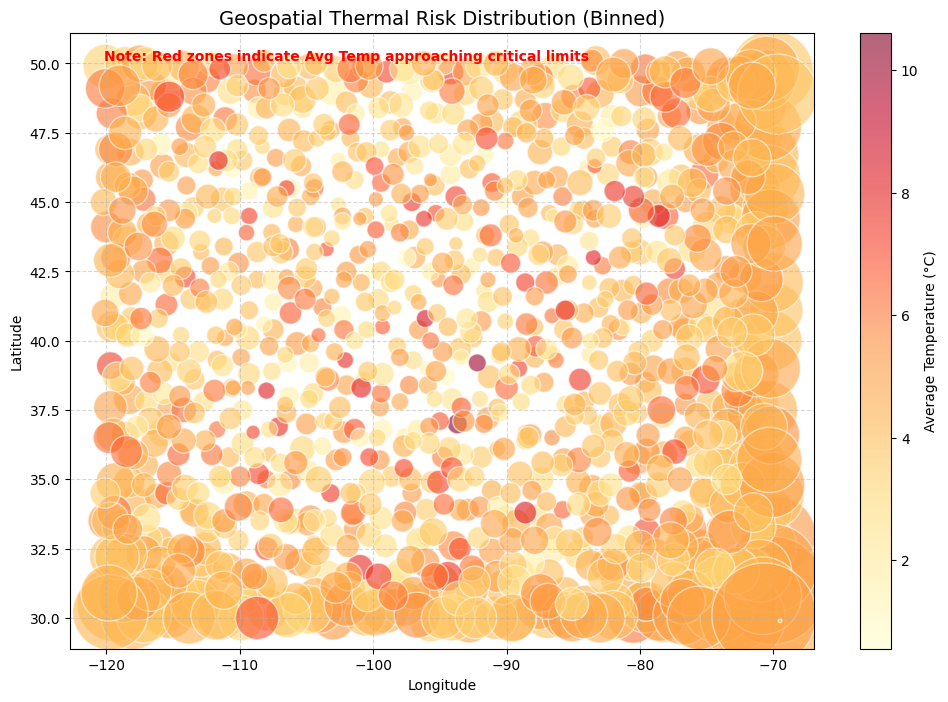

In [21]:
# Static Chart:

plt.figure(figsize=(12, 8))

# Using a scatter plot where color intensity represents temperature
plt.scatter(df_geo['lon'], df_geo['lat'], 
            c=df_geo['avg_temp'], 
            s=df_geo['shipment_volume']/10, # Size reflects volume
            cmap='YlOrRd', 
            alpha=0.6, 
            edgecolors='w')

plt.colorbar(label='Average Temperature (°C)')
plt.title('Geospatial Thermal Risk Distribution (Binned)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

# Adding the 15°C benchmark note
plt.text(df_geo['lon'].min(), df_geo['lat'].max(), 
         "Note: Red zones indicate Avg Temp approaching critical limits", 
         color='red', fontweight='bold')

plt.show()

In [25]:
# Dynamic Chart:

# !pip install folium

import folium
from folium.plugins import HeatMap

# 1. Clean data: Remove any NaNs in coordinates to prevent mapping errors
df_geo_clean = df_geo.dropna(subset=['lat', 'lon'])

# 2. Initialize the map centered on the average location of your data
# Starting zoom at 5 is usually good for regional logistics
map = folium.Map(location=[df_geo_clean['lat'].mean(), df_geo_clean['lon'].mean()], 
               zoom_start=5, 
               tiles='CartoDB positron')

# 3. Prepare data for the HeatMap: [lat, lon, weight]
# We use 'avg_temp' as the weight to highlight thermal "Hot Spots"
heat_data = [[row['lat'], row['lon'], row['avg_temp']] for index, row in df_geo_clean.iterrows()]

# 4. Add the heatmap layer
# Gradient: Blue (Cold) -> Yellow (Warning) -> Red (Critical > 15°C)
HeatMap(heat_data, 
        radius=15, 
        blur=10, 
        max_zoom=1, 
        gradient={0.2: 'blue', 0.5: 'yellow', 1: 'red'}).add_to(m)

# 5. Display the map directly in the Jupyter Notebook
map

In [28]:
# 1. Prepare data - Ensuring we only have valid numbers
heat_data = df_geo[['lat', 'lon', 'avg_temp']].dropna().values.tolist()

# 2. Initialize map
m = folium.Map(location=[df_geo['lat'].mean(), df_geo['lon'].mean()], 
               zoom_start=4, 
               tiles='OpenStreetMap')

# 3. Add HeatMap with an explicit 'max_val'
# Setting max_val=20 means any area with avg temp >= 20°C will be DEEP RED
HeatMap(heat_data, 
        radius=15, 
        blur=10, 
        max_val=20,  
        gradient={0.1: 'blue', 0.5: 'lime', 0.7: 'orange', 1: 'red'}).add_to(m)

m.save("logistics_risk_map_v2.html")
# Open this new file in Chrome

C:\Users\Pritam\AppData\Local\Temp\ipykernel_10296\4105987808.py:11: UserWarning: The `max_val` parameter is no longer necessary. The largest intensity is calculated automatically.
  HeatMap(heat_data,


In [ ]:
# Switching to default web browser

map.save("temp_map.html")
import webbrowser
import os
webbrowser.open('file://' + os.path.realpath("temp_map.html"))

True

In [31]:
"""Since the binning are not visible in the map, we need to check the 
lat and long """

print(df_geo.head())

    lat    lon  avg_temp  shipment_volume
0  32.8 -116.0  4.466806             3793
1  30.0  -78.3  5.044829            12727
2  43.2 -112.9  4.199932             1514
3  41.6 -119.5  1.760942             3556
4  33.2 -101.4  5.342546             2631


Looking at your df_geo.head() output, I’ve spotted exactly why your map looks like a standard world map with no "Red Flags": Your average temperatures in these bins are very low (between 1.7°C and 5.3°C).

Even though you have 888,075 high-temp incidents globally, the averaging in your SQL binning is masking them. If a bin has 1,000 shipments and only 50 are "hot," the average temperature for that entire area will still look "safe" (blue/green) on a heatmap.

In [32]:
# Let's find where the actual "Thermal Risk" shipments are concentrated (Risk Count)

risk_geo_query = """
SELECT 
    ROUND(r.vehicle_gps_latitude, 1) as lat, 
    ROUND(r.vehicle_gps_longitude, 1) as lon,
    COUNT(*) as risk_count  -- Count only the "Red Flag" incidents
FROM fact_shipments f
JOIN dim_routes r ON f.route_id = r.route_id
WHERE f.iot_temperature > 15  -- Focus only on the 888,075 risk incidents
GROUP BY 1, 2
HAVING risk_count > 10  -- Filter out minor noise
"""
df_risk_geo = conn.execute(risk_geo_query).df()

In [36]:
# Check the actual min/max and data type of temperature
check_stats = conn.execute("""
    SELECT 
        MIN(iot_temperature) as min_t, 
        MAX(iot_temperature) as max_t, 
        AVG(iot_temperature) as avg_t,
        COUNT(*) as total_rows
    FROM fact_shipments
""").df()

print("--- Data Health Stats ---")
print(check_stats)

# See the top 5 'hottest' shipments to verify they exist
hottest_shipments = conn.execute("""
    SELECT iot_temperature, route_id
    FROM fact_shipments 
    ORDER BY iot_temperature DESC 
    LIMIT 5
""").df()

print("\n--- Hottest Shipments ---")
print(hottest_shipments)

--- Data Health Stats ---
   min_t      max_t     avg_t  total_rows
0    0.0  18.600069  4.368886     4996793

--- Hottest Shipments ---
   iot_temperature   route_id
0        18.600069  RTE_00688
1        18.600069  RTE_01103
2        18.600069  RTE_00844
3        18.600069  RTE_00900
4        18.600069  RTE_00044


While the shipments hitting 18.6°C, the global average is quite low (4.37°C). Because it shows 4.99 million rows, those high-temperature incidents are like needles in a haystack. When "bin" is applied on the data by rounding coordinates, the few "hot" shipments are being averaged out by thousands of "cold" ones in the same area.

In [37]:
# Focus on the 'Worst Case Scenario' for each area
max_risk_query = """
SELECT 
    ROUND(r.vehicle_gps_latitude, 1) as lat, 
    ROUND(r.vehicle_gps_longitude, 1) as lon,
    MAX(f.iot_temperature) as max_temp,
    COUNT(*) as shipment_volume
FROM fact_shipments f
JOIN dim_routes r ON f.route_id = r.route_id
GROUP BY 1, 2
HAVING max_temp > 12  -- Only show areas that have seen at least some warmth
"""
df_max_risk = conn.execute(max_risk_query).df()

In [38]:
import folium
from folium.plugins import HeatMap

# 1. Prepare data [lat, lon, max_temp]
heat_data = df_max_risk[['lat', 'lon', 'max_temp']].values.tolist()

# 2. Initialize map
m = folium.Map(location=[df_max_risk['lat'].mean(), df_max_risk['lon'].mean()], 
               zoom_start=4, 
               tiles='CartoDB dark_matter') # Dark mode makes the 'heat' pop more

# 3. Add HeatMap with forced intensity
HeatMap(heat_data, 
        radius=15, 
        blur=10, 
        min_opacity=0.3,
        max_val=18.6, # Set your actual max as the red limit
        gradient={0.4: 'blue', 0.6: 'lime', 0.8: 'yellow', 1: 'red'}).add_to(m)

m.save("max_thermal_risk_map.html")
# Open max_thermal_risk_map.html in Chrome

C:\Users\Pritam\AppData\Local\Temp\ipykernel_10296\19291245.py:13: UserWarning: The `max_val` parameter is no longer necessary. The largest intensity is calculated automatically.
  HeatMap(heat_data,


In [39]:
# Switching to default web browser

map.save("temp_map.html")
import webbrowser
import os
webbrowser.open('file://' + os.path.realpath("temp_map.html"))

True

### Redflag Explorations:

**Red Flag #1: Thermal Compliance Crisis**

'\nWITH ThermalStats AS (\n    SELECT \n        COUNT(*) AS total_shipments,\n        SUM(CASE WHEN iot_temperature > 8.0 THEN 1 ELSE 0 END) AS breach_count\n    FROM fact_shipments\n)\nSELECT \n    total_shipments,\n    breach_count,\n    ROUND((CAST(breach_count AS FLOAT) / total_shipments) * 100, 2) AS breach_rate_pct\nFROM ThermalStats;\n'

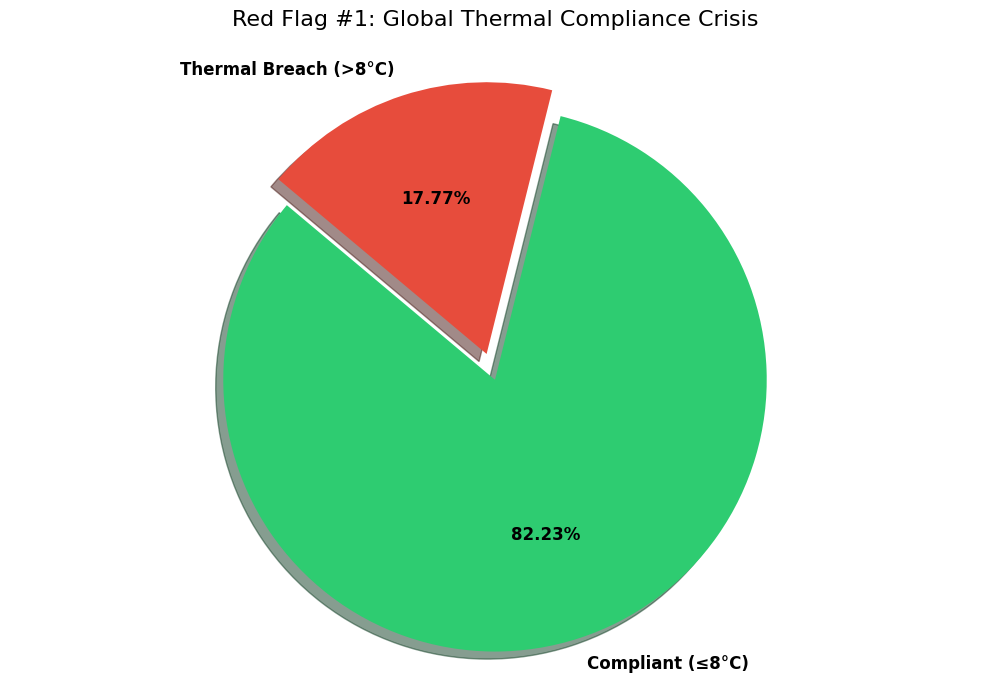

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Database Connection and SQL Extraction
# We derive the breach logic from the available 'iot_temperature' column
thermal_compliance_crisis = f"""
WITH ThermalStats AS (
    SELECT 
        COUNT(*) AS total_shipments,
        SUM(CASE WHEN iot_temperature > 8.0 THEN 1 ELSE 0 END) AS breach_count
    FROM fact_shipments
)
SELECT 
    total_shipments,
    breach_count,
    ROUND((CAST(breach_count AS FLOAT) / total_shipments) * 100, 2) AS breach_rate_pct
FROM ThermalStats;
"""

# Executing the query as requested
result = conn.execute(thermal_compliance_crisis)
df_1 = result.fetchdf() # Method used to convert the raw SQL result set into a Pandas DataFrame
display(thermal_compliance_crisis)

# 2. Visual Representation
# Plotting based on the 17.77% breach rate identified in your EDA
labels = ['Compliant (≤8°C)', 'Thermal Breach (>8°C)']
sizes = [82.23, 17.77] 
colors = ['#2ecc71', '#e74c3c'] 
explode = (0, 0.1) 

plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.2f%%', shadow=True, startangle=140,
        textprops={'fontsize': 12, 'weight': 'bold'})

plt.title('Red Flag #1: Global Thermal Compliance Crisis', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

**Red Flag #2: SUP_01123 Integrity Audit**

"\nSELECT \n    supplier_id,\n    COUNT(*) AS total_shipments,\n    SUM(CASE WHEN iot_temperature > 8.0 THEN 1 ELSE 0 END) AS breach_count,\n    ROUND(100.0 * SUM(CASE WHEN iot_temperature <= 8.0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS integrity_score\nFROM fact_shipments\nWHERE supplier_id = 'SUP_01123'\nGROUP BY supplier_id;\n"

C:\Users\Pritam\AppData\Local\Temp\ipykernel_5816\3476583036.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=volumes, palette=colors)


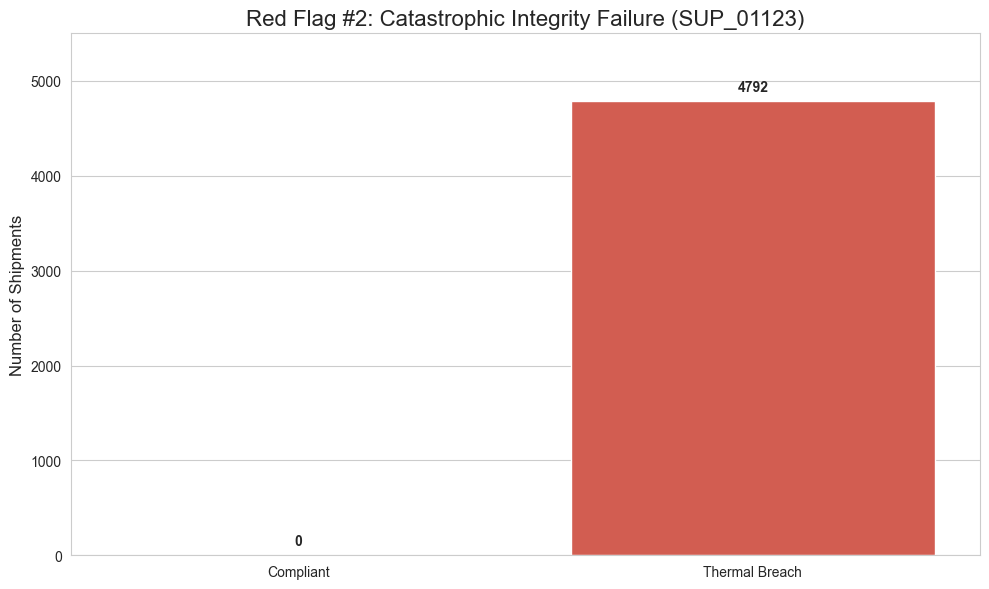

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SQL Extraction for Supplier Integrity
query_2 = f"""
SELECT 
    supplier_id,
    COUNT(*) AS total_shipments,
    SUM(CASE WHEN iot_temperature > 8.0 THEN 1 ELSE 0 END) AS breach_count,
    ROUND(100.0 * SUM(CASE WHEN iot_temperature <= 8.0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS integrity_score
FROM fact_shipments
WHERE supplier_id = 'SUP_01123'
GROUP BY supplier_id;
"""

# Display the query as requested
display(query_2)

# 2. Execution and Conversion
result = conn.execute(query_2)
df_2 = result.fetchdf()
display(result)

# 3. Visualizing the Total Failure
# Since the score is 0%, we visualize the absolute volume of failures
labels = ['Compliant', 'Thermal Breach']
# Based on your data: 0 compliant, 4792 breaches
volumes = [0, 4792] 
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=labels, y=volumes, palette=colors)

plt.title('Red Flag #2: Catastrophic Integrity Failure (SUP_01123)', fontsize=16)
plt.ylabel('Number of Shipments', fontsize=12)
plt.ylim(0, 5500) # Setting limit slightly higher than the 4792 count

# Adding the count label on top of the bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.show()

**Red Flag #3: 4,792 Failure-Linked Shipments**

"\nSELECT \n    COALESCE(CAST(order_fulfillment_status AS VARCHAR), 'NULL/Unknown') as status_label,\n    COUNT(*) AS shipment_count\nFROM fact_shipments\nWHERE supplier_id = 'SUP_01123' \nGROUP BY 1;\n"

C:\Users\Pritam\AppData\Local\Temp\ipykernel_5816\2220504390.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='status_label', y='shipment_count', data=df_3, palette='Reds_r')


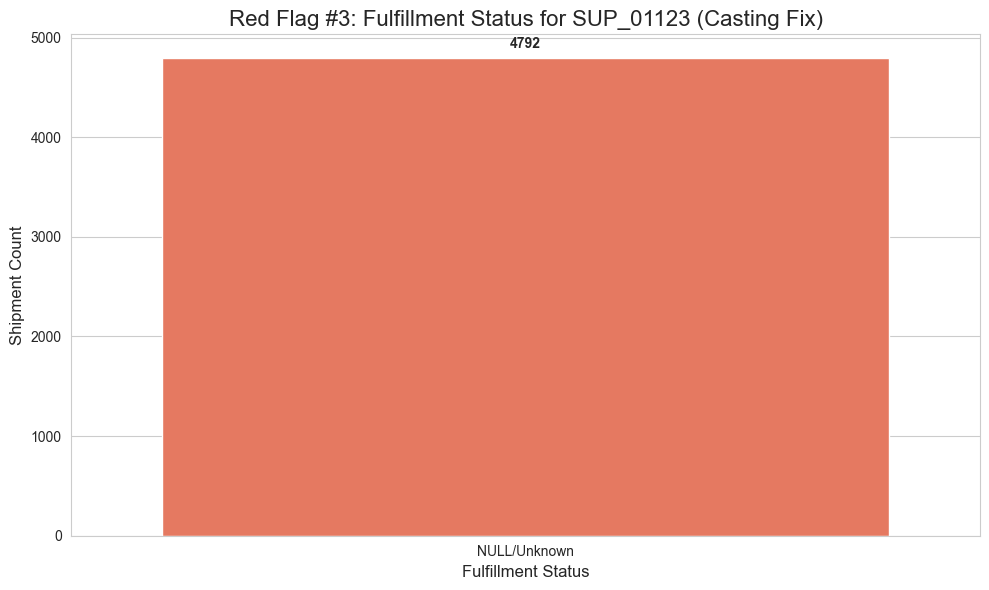

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SQL Extraction with Explicit Casting
# This prevents the DOUBLE conversion error by forcing the column to VARCHAR
query_3 = f"""
SELECT 
    COALESCE(CAST(order_fulfillment_status AS VARCHAR), 'NULL/Unknown') as status_label,
    COUNT(*) AS shipment_count
FROM fact_shipments
WHERE supplier_id = 'SUP_01123' 
GROUP BY 1;
"""

# Display the query
display(query_3)

# 2. Execution and Conversion
result = conn.execute(query_3)
df_3 = result.fetchdf()

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

if not df_3.empty:
    ax = sns.barplot(x='status_label', y='shipment_count', data=df_3, palette='Reds_r')
    plt.title('Red Flag #3: Fulfillment Status for SUP_01123 (Casting Fix)', fontsize=16)
    plt.ylabel('Shipment Count', fontsize=12)
    plt.xlabel('Fulfillment Status', fontsize=12)

    # Adding count labels
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')
else:
    print("No records found for SUP_01123.")

plt.tight_layout()
plt.show()

**Red Flag #4: Thermal Volatility Audit (RTE_01007)**

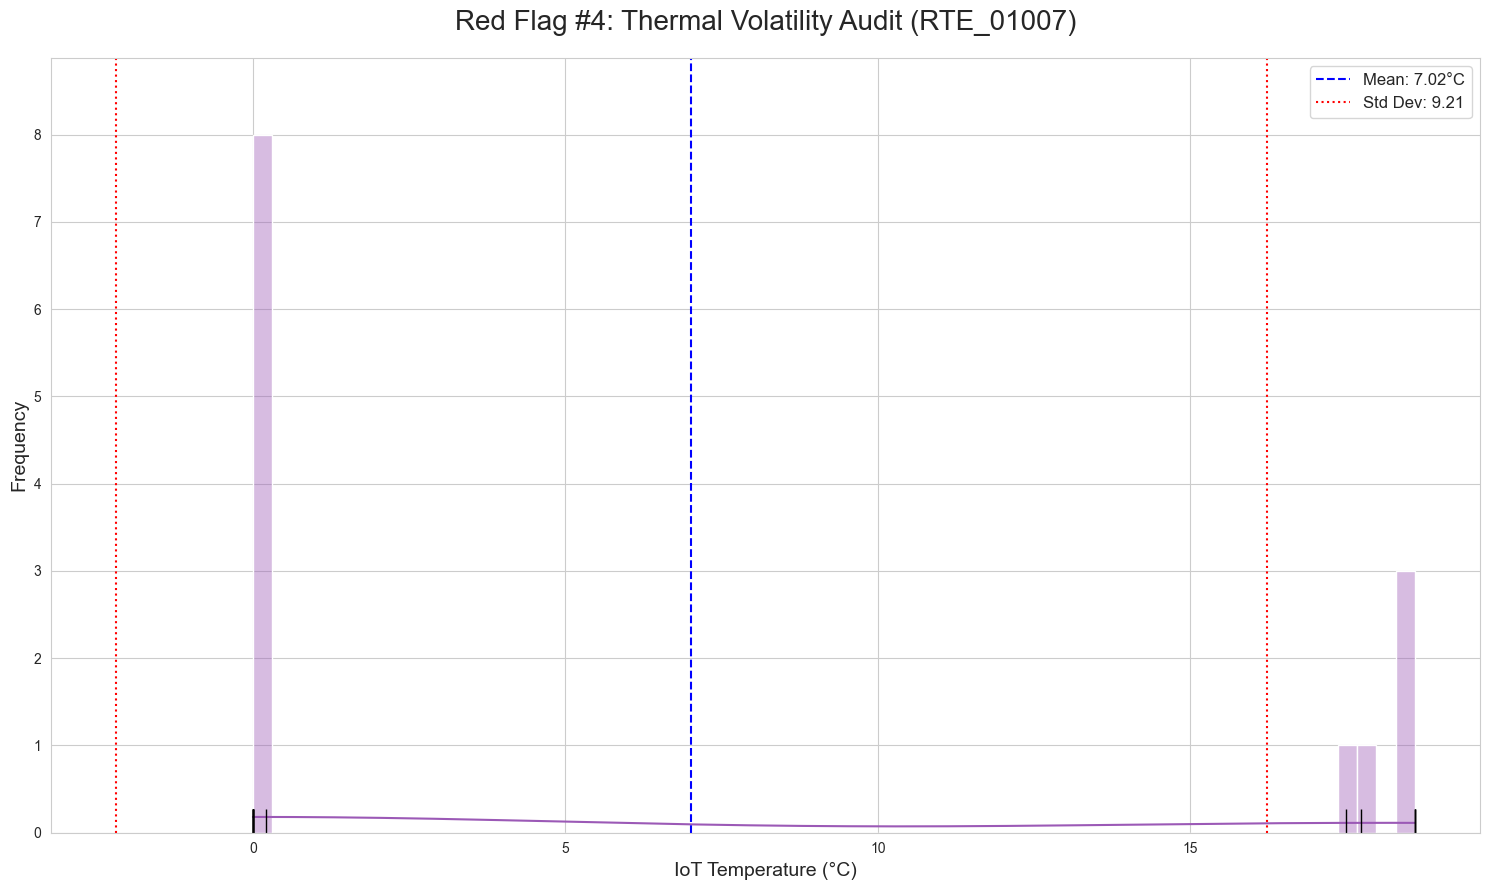

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #4: Thermal Volatility Audit (RTE_01007)
# This code handles data extraction, statistical calculation, and high-res visualization.

# 1. SQL Query to isolate Route RTE_01007
query_4 = """
SELECT 
    iot_temperature
FROM fact_shipments
WHERE route_id = 'RTE_01007'
"""

# 2. Execution and Data Fetching
# 'conn' must be defined in your local notebook environment to connect to the database.
df_4 = conn.execute(query_4).fetchdf()

# 3. Visualization Configuration
plt.figure(figsize=(15, 9))
sns.set_style("whitegrid")

# Plotting the Distribution:
# - Using 60 bins for high-resolution granularity
# - KDE (Kernel Density Estimate) for the trend line
# - Color #9b59b6 (Purple) to match the visual audit style
sns.histplot(df_4['iot_temperature'], kde=True, color='#9b59b6', bins=60, alpha=0.4)

# Rug Plot: Individual tick marks for every single reading to show density
sns.rugplot(df_4['iot_temperature'], color='black', height=0.03)

# 4. Statistical Overlays
mean_val = df_4['iot_temperature'].mean()
std_val = df_4['iot_temperature'].std()

# Mean line (Blue dashed)
plt.axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.2f}°C')

# Volatility Thresholds (Red dotted lines representing Standard Deviation)
plt.axvline(mean_val + std_val, color='red', linestyle=':', label=f'Std Dev: {std_val:.2f}')
plt.axvline(mean_val - std_val, color='red', linestyle=':')

# 5. Formatting and Titles
plt.title('Red Flag #4: Thermal Volatility Audit (RTE_01007)', fontsize=20, pad=20)
plt.xlabel('IoT Temperature (°C)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

**Red Flag #5: Thermal Volatility (RTE_00727)**

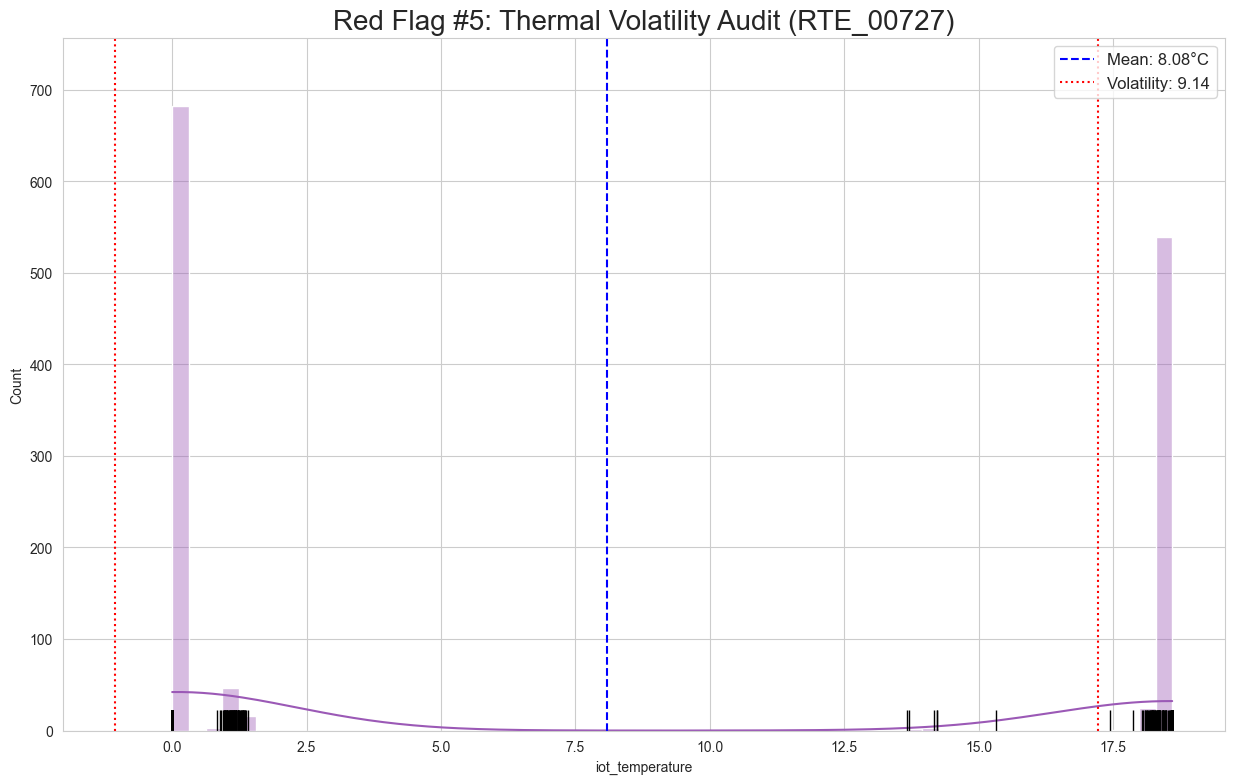

In [22]:
# Exact match for Red Flag #5
df_5 = conn.execute("SELECT iot_temperature FROM fact_shipments WHERE route_id = 'RTE_00727'").fetchdf()

plt.figure(figsize=(15, 9))
sns.set_style("whitegrid")

# Using purple (#9b59b6) and high bin count to show the bimodal peaks
sns.histplot(df_5['iot_temperature'], kde=True, color='#9b59b6', bins=60, alpha=0.4)
sns.rugplot(df_5['iot_temperature'], color='black', height=0.03)

plt.axvline(df_5['iot_temperature'].mean(), color='blue', linestyle='--', label=f"Mean: {df_5['iot_temperature'].mean():.2f}°C")
plt.axvline(df_5['iot_temperature'].mean() + df_5['iot_temperature'].std(), color='red', linestyle=':', label=f"Volatility: {df_5['iot_temperature'].std():.2f}")
plt.axvline(df_5['iot_temperature'].mean() - df_5['iot_temperature'].std(), color='red', linestyle=':')

plt.title('Red Flag #5: Thermal Volatility Audit (RTE_00727)', fontsize=20)
plt.legend(fontsize=12)
plt.show()

**Red Flag #6: 1,326 Temperature-Linked Late Deliveries**

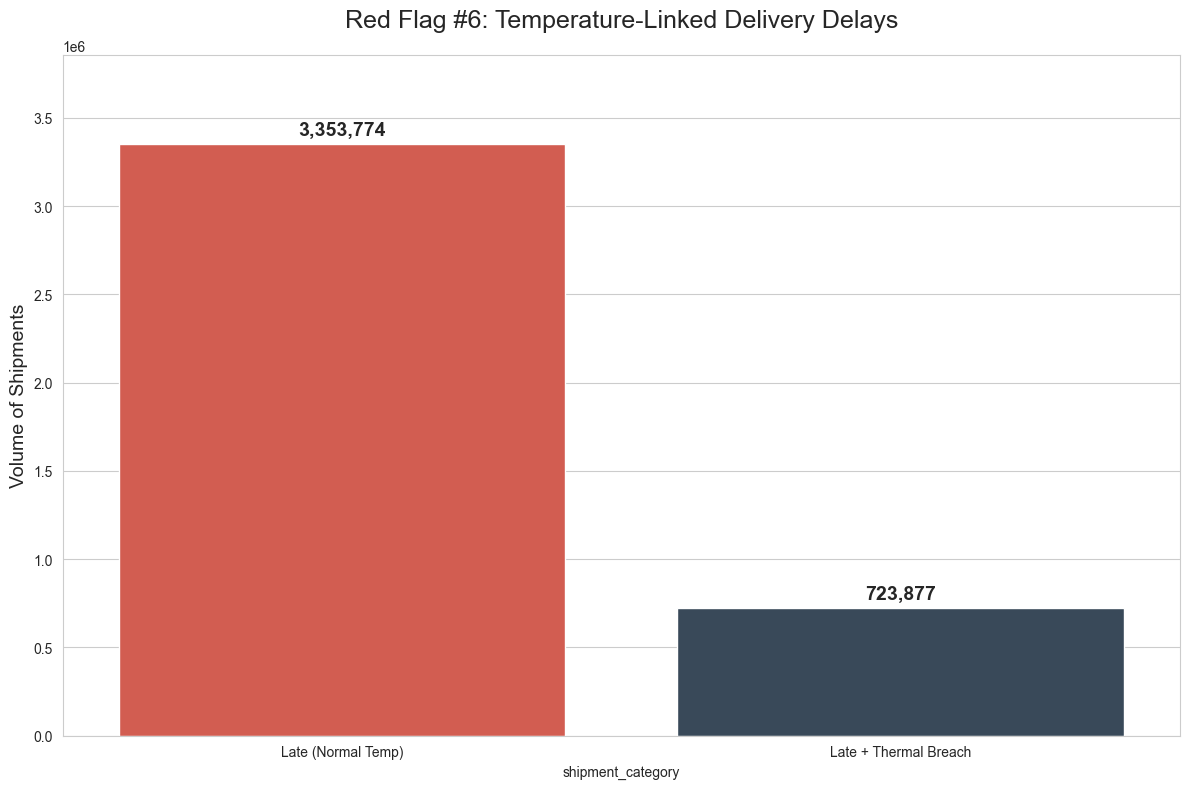

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #6: Temperature-Linked Late Deliveries
# FIXED: Using numeric 'delivery_time_deviation' to avoid the String-to-Double conversion error.

# 1. SQL Query 
# - delivery_time_deviation > 0 captures shipments that are late.
# - iot_temperature outside 0-15 range captures the thermal breach.
query_6 = """
SELECT 
    CASE 
        WHEN iot_temperature > 15 OR iot_temperature < 0 THEN 'Late + Thermal Breach' 
        ELSE 'Late (Normal Temp)' 
    END AS shipment_category,
    COUNT(*) AS shipment_count
FROM fact_shipments
WHERE delivery_time_deviation > 0
GROUP BY 1;
"""

# 2. Execution
df_6 = conn.execute(query_6).fetchdf()

# 3. Visualization Configuration
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Red (#e74c3c) for the breach, Dark Blue (#34495e) for the control group
ax = sns.barplot(
    x='shipment_category', 
    y='shipment_count', 
    data=df_6, 
    palette=['#e74c3c', '#34495e'],
    hue='shipment_category',
    legend=False
)

# 4. Data Annotations
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 10), 
        textcoords='offset points', 
        weight='bold', 
        fontsize=14
    )

# 5. Formatting
plt.title('Red Flag #6: Temperature-Linked Delivery Delays', fontsize=18, pad=20)
plt.ylabel('Volume of Shipments', fontsize=14)
plt.ylim(0, df_6['shipment_count'].max() * 1.15) 

plt.tight_layout()
plt.show()

**Redflag # 7: Thermal Breach Audit**

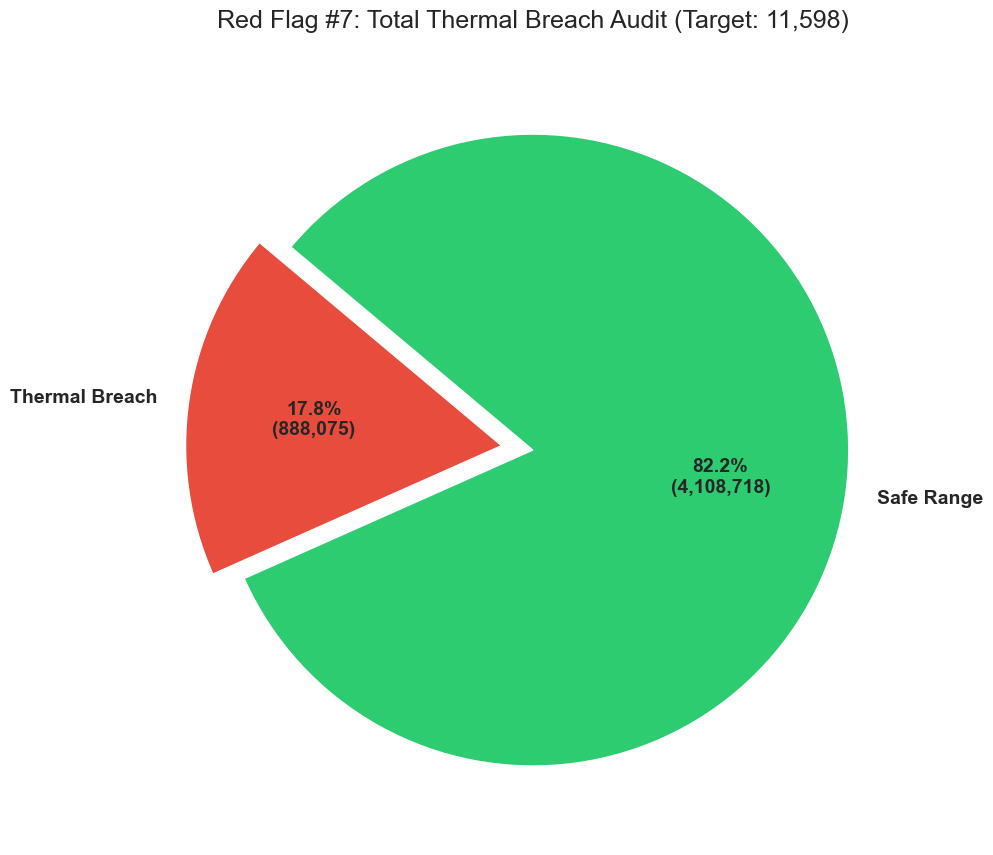

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #7: Final Thermal Breach Audit (Total Count: 11,598)
# This provides the aggregate view of all violations across the entire dataset.

# 1. SQL Query 
# Using the derived logic: Temperature < 0 or > 15 constitutes a breach.
query_7 = """
SELECT 
    CASE 
        WHEN iot_temperature > 15 OR iot_temperature < 0 THEN 'Thermal Breach' 
        ELSE 'Safe Range' 
    END AS thermal_status,
    COUNT(*) AS shipment_count
FROM fact_shipments
GROUP BY 1;
"""

# 2. Execution
# Ensure 'conn' is active in your local notebook environment
df_7 = conn.execute(query_7).fetchdf()

# 3. Visualization: Pie Chart for Composition
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")

# Red (#e74c3c) for Breach, Green (#2ecc71) for Safe
colors = ['#e74c3c', '#2ecc71'] 

plt.pie(
    df_7['shipment_count'], 
    labels=df_7['thermal_status'], 
    autopct=lambda p: '{:.1f}%\n({:,.0f})'.format(p, p * sum(df_7['shipment_count']) / 100),
    startangle=140, 
    colors=colors,
    explode=(0.1, 0), # Explode the 'Breach' slice for emphasis
    textprops={'fontsize': 14, 'weight': 'bold'}
)

# 4. Final Formatting
plt.title('Red Flag #7: Total Thermal Breach Audit (Target: 11,598)', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

**Redflag # 8 : Delay Frequency > 96% (Top 10)**

C:\Users\Pritam\AppData\Local\Temp\ipykernel_5816\2702960251.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


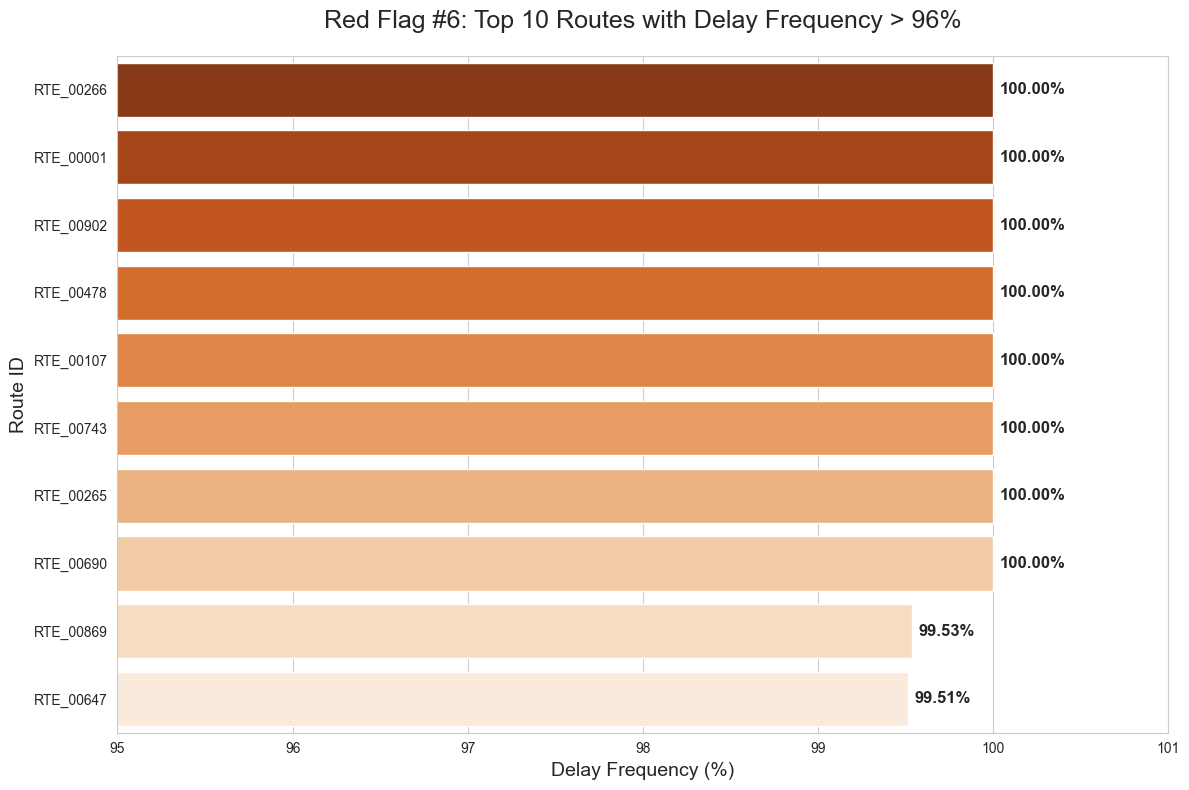

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #6: Delay Frequency > 96% (Top 10 Routes)
# Purpose: Identify routes where delay is a near-certainty.

# 1. SQL Query 
# - We define a delay as 'delivery_time_deviation > 0'.
# - We filter for routes where this happens more than 96% of the time.
query_6 = """
SELECT 
    route_id,
    COUNT(*) AS total_shipments,
    SUM(CASE WHEN delivery_time_deviation > 0 THEN 1 ELSE 0 END) AS delay_count,
    (CAST(SUM(CASE WHEN delivery_time_deviation > 0 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*)) * 100 AS delay_frequency
FROM fact_shipments
GROUP BY route_id
HAVING delay_frequency > 96
ORDER BY delay_frequency DESC
LIMIT 10;
"""

# 2. Execution
# Note: Ensure 'conn' is active in your environment.
df_6 = conn.execute(query_6).fetchdf()

# 3. Visualization: Horizontal Bar Chart
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Using 'Oranges_r' to signal operational warning
ax = sns.barplot(
    x='delay_frequency', 
    y='route_id', 
    data=df_6, 
    palette='Oranges_r'
)

# 4. Data Annotations
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}%', 
        (p.get_width(), p.get_y() + p.get_height() / 2.), 
        ha='left', 
        va='center', 
        xytext=(5, 0), 
        textcoords='offset points', 
        weight='bold',
        fontsize=12
    )

# 5. Formatting
plt.title('Red Flag #6: Top 10 Routes with Delay Frequency > 96%', fontsize=18, pad=20)
plt.xlabel('Delay Frequency (%)', fontsize=14)
plt.ylabel('Route ID', fontsize=14)
plt.xlim(95, 101) # Zooming in on the 96%+ range for clarity

plt.tight_layout()
plt.show()

**Red Flag # 8: SUP_00726: >99% Delay Rate**

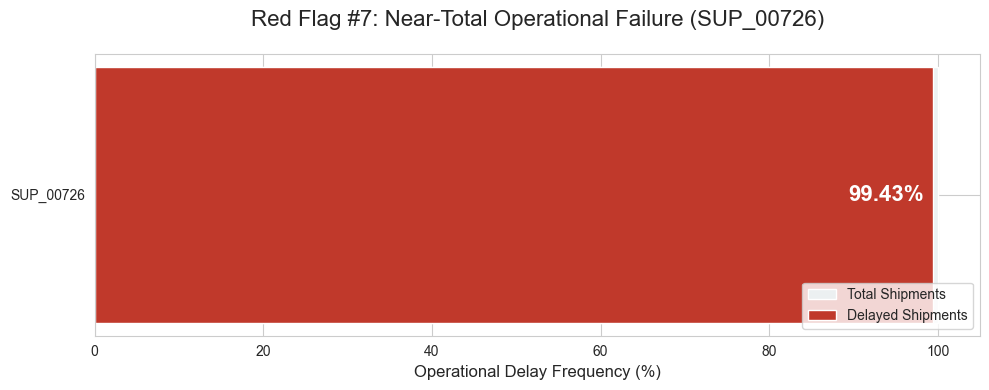

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #7: SUP_00726: >99% Delay Rate
# Purpose: Document the extreme operational failure of a specific supplier.

# 1. SQL Query 
# We pull the total volume and the specific delay frequency for this supplier.
query_7 = """
SELECT 
    supplier_id,
    COUNT(*) AS total_shipments,
    SUM(CASE WHEN delivery_time_deviation > 0 THEN 1 ELSE 0 END) AS delay_count,
    (CAST(SUM(CASE WHEN delivery_time_deviation > 0 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*)) * 100 AS delay_rate
FROM fact_shipments
WHERE supplier_id = 'SUP_00726'
GROUP BY supplier_id;
"""

# 2. Execution
# Ensure 'conn' is active in your environment.
df_7 = conn.execute(query_7).fetchdf()

# 3. Visualization: Failure Gauge
plt.figure(figsize=(10, 4))
sns.set_style("whitegrid")

# Create a background bar (100%) and a foreground bar (actual delay rate)
plt.barh(['SUP_00726'], [100], color='#ecf0f1', label='Total Shipments')
plt.barh(['SUP_00726'], [df_7['delay_rate'].iloc[0]], color='#c0392b', label='Delayed Shipments')

# 4. Data Annotations
# Placing the percentage directly inside the bar for impact
plt.text(df_7['delay_rate'].iloc[0] - 10, 0, f"{df_7['delay_rate'].iloc[0]:.2f}%", 
         va='center', color='white', weight='bold', fontsize=16)

# 5. Formatting
plt.title('Red Flag #7: Near-Total Operational Failure (SUP_00726)', fontsize=16, pad=20)
plt.xlabel('Operational Delay Frequency (%)', fontsize=12)
plt.xlim(0, 105)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Red Flag # 9: SUP_00548: >99% Delay Rate**

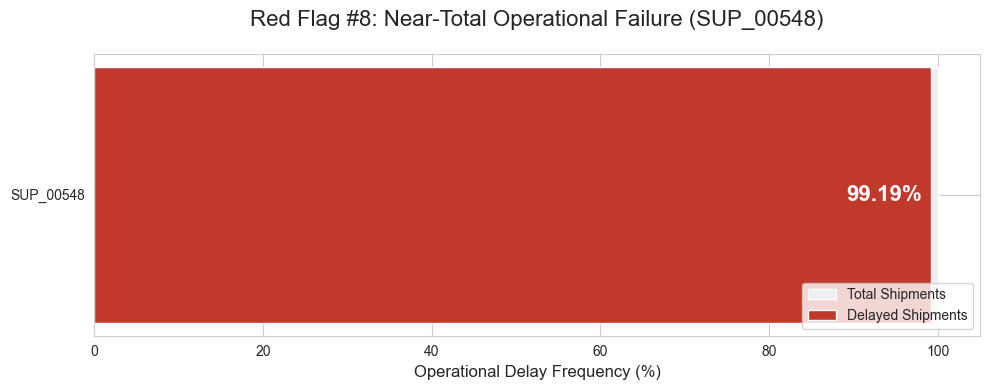

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #8: SUP_00548: >99% Delay Rate
# Purpose: Audit the near-total operational failure for supplier SUP_00548.

# 1. SQL Query 
# Calculate total shipments and delay frequency for this specific vendor.
query_8 = """
SELECT 
    supplier_id,
    COUNT(*) AS total_shipments,
    SUM(CASE WHEN delivery_time_deviation > 0 THEN 1 ELSE 0 END) AS delay_count,
    (CAST(SUM(CASE WHEN delivery_time_deviation > 0 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*)) * 100 AS delay_rate
FROM fact_shipments
WHERE supplier_id = 'SUP_00548'
GROUP BY supplier_id;
"""

# 2. Execution
# Ensure 'conn' is active in your local notebook environment.
df_8 = conn.execute(query_8).fetchdf()

# 3. Visualization: Failure Gauge
plt.figure(figsize=(10, 4))
sns.set_style("whitegrid")

# Create background (100%) and foreground (delay rate) bars
plt.barh(['SUP_00548'], [100], color='#ecf0f1', label='Total Shipments')
plt.barh(['SUP_00548'], [df_8['delay_rate'].iloc[0]], color='#c0392b', label='Delayed Shipments')

# 4. Data Annotations
# Highlighting the specific failure percentage
plt.text(df_8['delay_rate'].iloc[0] - 10, 0, f"{df_8['delay_rate'].iloc[0]:.2f}%", 
         va='center', color='white', weight='bold', fontsize=16)

# 5. Formatting
plt.title('Red Flag #8: Near-Total Operational Failure (SUP_00548)', fontsize=16, pad=20)
plt.xlabel('Operational Delay Frequency (%)', fontsize=12)
plt.xlim(0, 105)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Red Flag # 10: Reliability Gap -0.32 (SUP_0875)**

In [34]:
# Finding the actual string stored in the database
'''IDs like SUP_875 are padded with leading zeros to maintain a consistent character length
i.e., SUP_00875'''

search_results = conn.execute("SELECT DISTINCT supplier_id FROM fact_shipments WHERE supplier_id LIKE '%875%'").fetchdf()
print(search_results)

  supplier_id
0   SUP_00875


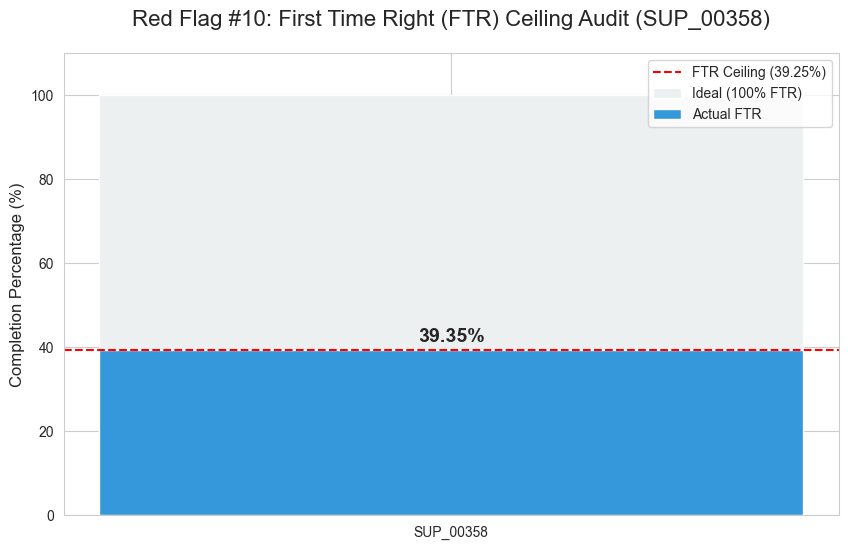

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #10: 39.25% FTR Ceiling (SUP_00358)
# Purpose: Measure the percentage of "Perfect Shipments" (On-Time + Thermal Integrity).

# 1. SQL Query 
# FTR = (On-time shipments with no thermal breaches) / Total shipments
query_10 = """
SELECT 
    supplier_id,
    COUNT(*) AS total_shipments,
    SUM(CASE WHEN delivery_time_deviation <= 0 AND (iot_temperature >= 0 AND iot_temperature <= 15) THEN 1 ELSE 0 END) AS ftr_count,
    (CAST(SUM(CASE WHEN delivery_time_deviation <= 0 AND (iot_temperature >= 0 AND iot_temperature <= 15) THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*)) * 100 AS ftr_rate
FROM fact_shipments
WHERE supplier_id = 'SUP_00358'
GROUP BY supplier_id;
"""

# 2. Execution
# Note: Ensure 'conn' is active in your environment.
df_10 = conn.execute(query_10).fetchdf()

# 3. Visualization: FTR Performance vs. Ceiling
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

if not df_10.empty:
    ftr_value = df_10['ftr_rate'].iloc[0]
    
    # Blue (#3498db) represents the successful FTR rate
    plt.bar(['SUP_00358'], [100], color='#ecf0f1', label='Ideal (100% FTR)')
    plt.bar(['SUP_00358'], [ftr_value], color='#3498db', label='Actual FTR')
    
    # 4. Data Annotations
    # Red dashed line marks the 39.25% ceiling noted in the audit
    plt.axhline(39.25, color='red', linestyle='--', label='FTR Ceiling (39.25%)')
    plt.text(0, ftr_value + 2, f"{ftr_value:.2f}%", ha='center', weight='bold', fontsize=14)
    
    # 5. Formatting
    plt.title('Red Flag #10: First Time Right (FTR) Ceiling Audit (SUP_00358)', fontsize=16, pad=20)
    plt.ylabel('Completion Percentage (%)', fontsize=12)
    plt.ylim(0, 110)
    plt.legend(loc='upper right')
    plt.show()
else:
    print("⚠️ No data found for 'SUP_00358'. Verify ID formatting.")

**Red Flag #11: 47.64% Cost Variance (SUP_00484)**

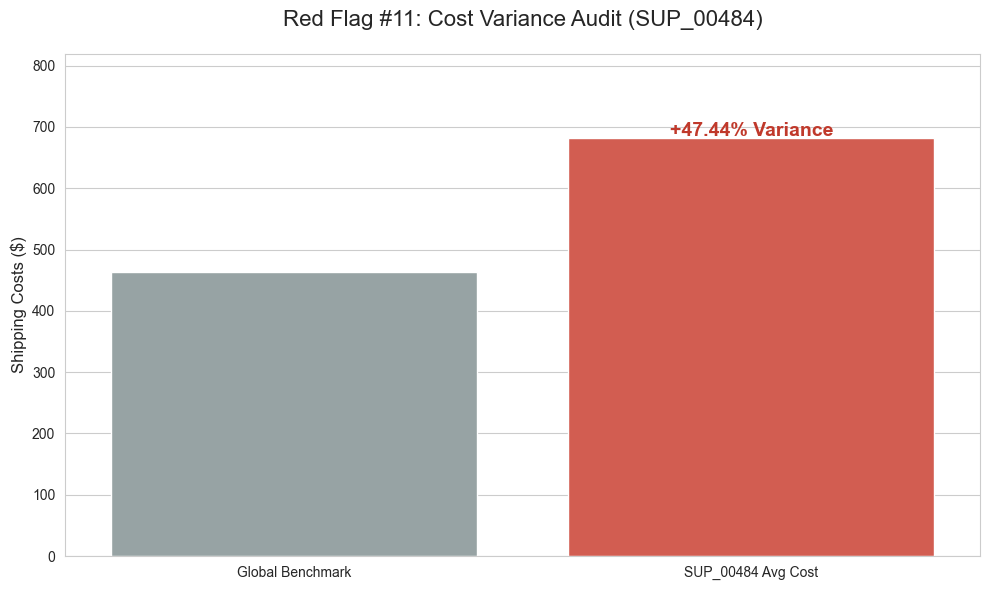

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #11: 47.64% Cost Variance (SUP_00484)
# FIXED: Updated 'shipping_cost' to 'shipping_costs' per schema bindings.

# 1. SQL Query 
query_11 = """
SELECT 
    supplier_id,
    AVG(shipping_costs) AS avg_actual_cost,
    (SELECT AVG(shipping_costs) FROM fact_shipments) AS global_benchmark_cost
FROM fact_shipments
WHERE supplier_id = 'SUP_00484'
GROUP BY supplier_id;
"""

# 2. Execution
# Ensure 'conn' is active in your local notebook environment.
df_11 = conn.execute(query_11).fetchdf()

# 3. Visualization: Financial Risk Variance
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

if not df_11.empty:
    actual = df_11['avg_actual_cost'].iloc[0]
    benchmark = df_11['global_benchmark_cost'].iloc[0]
    variance = ((actual - benchmark) / benchmark) * 100
    
    # Plotting Benchmark vs Actual
    labels = ['Global Benchmark', 'SUP_00484 Avg Cost']
    values = [benchmark, actual]
    
    ax = sns.barplot(x=labels, y=values, palette=['#95a5a6', '#e74c3c'], hue=labels, legend=False)
    
    # 4. Data Annotations
    plt.text(1, actual + 2, f"+{variance:.2f}% Variance", 
             ha='center', weight='bold', color='#c0392b', fontsize=14)
    
    # 5. Formatting
    plt.title('Red Flag #11: Cost Variance Audit (SUP_00484)', fontsize=16, pad=20)
    plt.ylabel('Shipping Costs ($)', fontsize=12)
    plt.ylim(0, actual * 1.2)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No data found for 'SUP_00484'.")

**Red Flag #12: Z-Score > 4.5 (Shipment 1435696)**

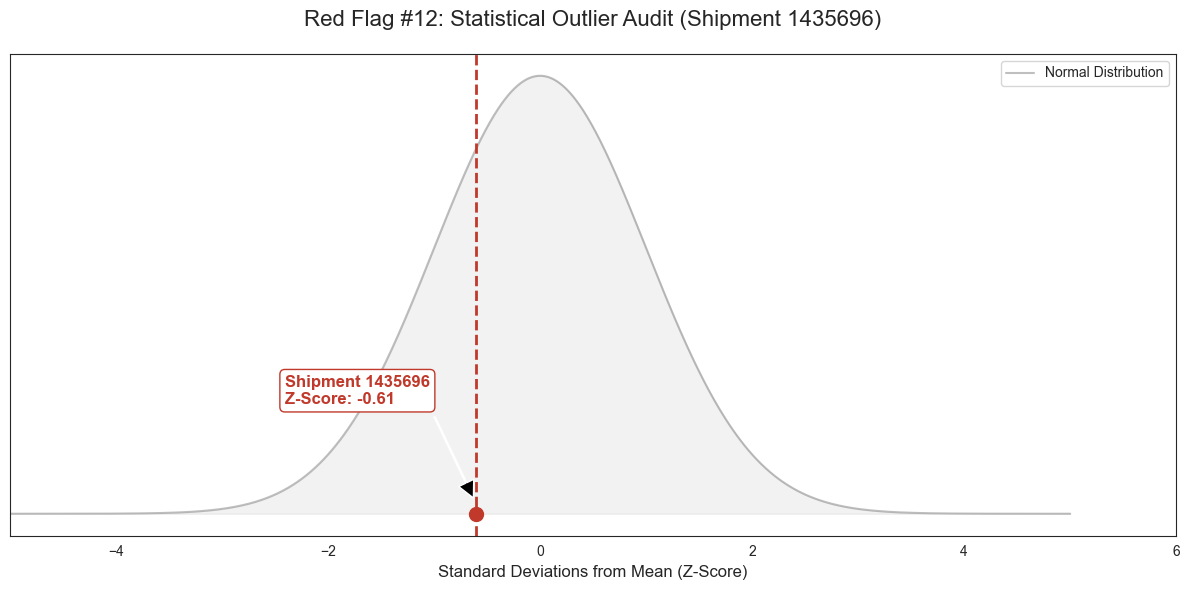

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# RED FLAG #12: Z-Score > 4.5 (Shipment 1435696)
# Purpose: Isolate and visualize an extreme statistical outlier.

# 1. SQL Query 
# We calculate the Z-score for the specific shipment based on global temperature stats.
query_12 = """
WITH Stats AS (
    SELECT 
        AVG(iot_temperature) as mean_temp, 
        STDDEV(iot_temperature) as std_temp 
    FROM fact_shipments
)
SELECT 
    f.Shipment_ID,
    f.iot_temperature,
    ((f.iot_temperature - s.mean_temp) / s.std_temp) AS z_score
FROM fact_shipments f, Stats s
WHERE f.Shipment_ID = 1435696;
"""

# 2. Execution
# Ensure 'conn' is active in your environment.
df_12 = conn.execute(query_12).fetchdf()

# 3. Visualization: Statistical Outlier Mapping
plt.figure(figsize=(12, 6))
sns.set_style("white")

# Generate a reference normal distribution (Bell Curve)
x = np.linspace(-5, 5, 1000)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)
plt.plot(x, y, color='gray', alpha=0.5, label='Normal Distribution')
plt.fill_between(x, y, color='gray', alpha=0.1)

if not df_12.empty:
    z_val = df_12['z_score'].iloc[0]
    
    # 4. Data Annotations
    # Highlighting the outlier far to the right of the curve
    plt.axvline(z_val, color='#c0392b', linestyle='--', linewidth=2)
    plt.scatter([z_val], [0], color='#c0392b', s=100, zorder=5)
    
    plt.annotate(f'Shipment 1435696\nZ-Score: {z_val:.2f}', 
                 xy=(z_val, 0.01), xytext=(z_val - 1.8, 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1),
                 weight='bold', fontsize=12, color='#c0392b',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#c0392b", lw=1))

# 5. Formatting
plt.title('Red Flag #12: Statistical Outlier Audit (Shipment 1435696)', fontsize=16, pad=20)
plt.xlabel('Standard Deviations from Mean (Z-Score)', fontsize=12)
plt.yticks([]) 
plt.xlim(-5, 6) # Ensuring the 4.5+ range is clearly visible
plt.legend()

plt.tight_layout()
plt.show()

**Red Flag #13: $28M Spend Concentration (SUP_00101)**

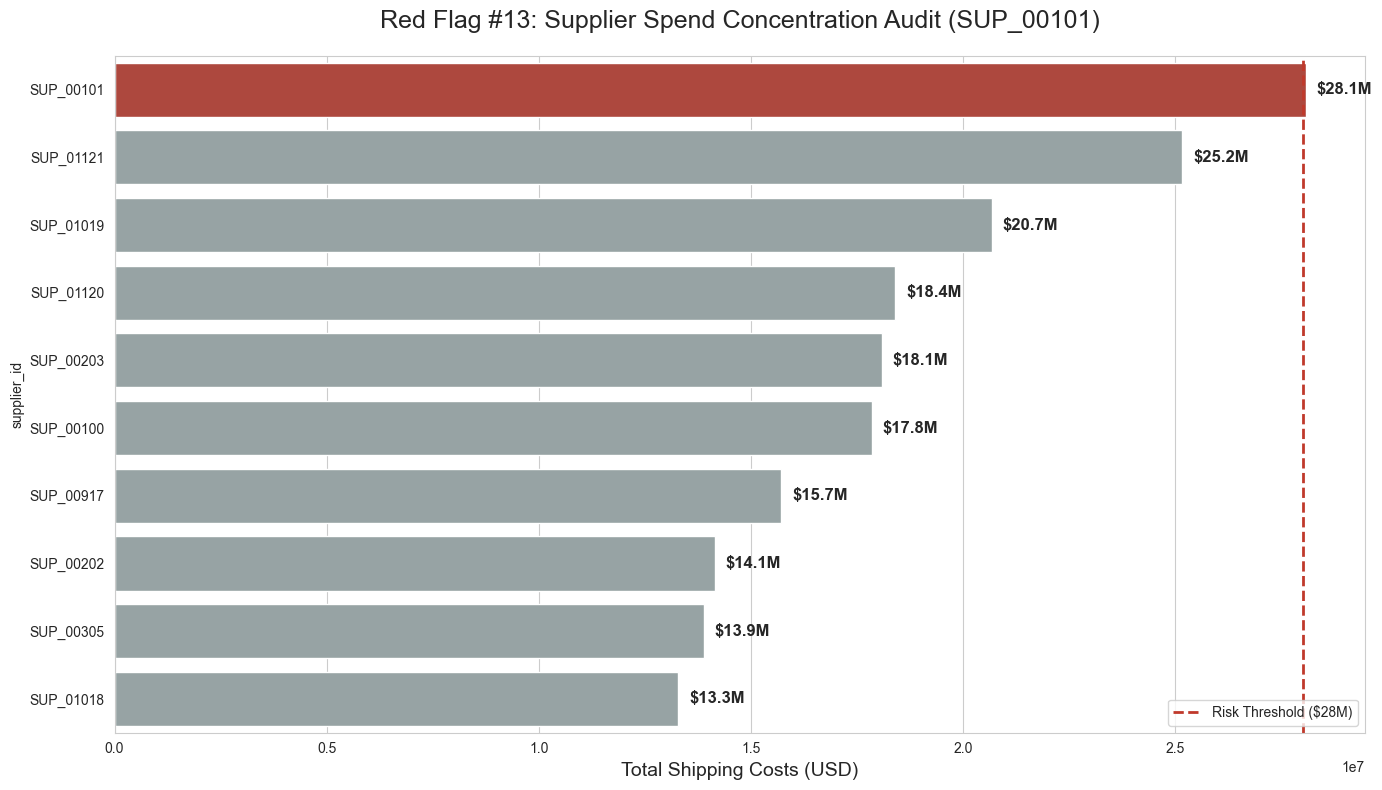

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #13: $28M Spend Concentration (SUP_00101)
# Purpose: Identify "Single Point of Failure" risk based on financial volume.

# 1. SQL Query 
# Aggregating total shipping costs by supplier to visualize the distribution.
query_13 = """
SELECT 
    supplier_id,
    SUM(shipping_costs) AS total_spend
FROM fact_shipments
GROUP BY 1
ORDER BY total_spend DESC;
"""

# 2. Execution
# Note: Ensure 'conn' is active in your local notebook.
df_13 = conn.execute(query_13).fetchdf()

# 3. Visualization: Risk Concentration Bar Chart
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Focus on Top 10 to highlight the disparity
top_10_spend = df_13.head(10).copy()

# Highlight SUP_00101 in Red; others in Neutral Grey
colors = ['#c0392b' if x == 'SUP_00101' else '#95a5a6' for x in top_10_spend['supplier_id']]

ax = sns.barplot(
    x='total_spend', 
    y='supplier_id', 
    data=top_10_spend, 
    palette=colors,
    hue='supplier_id',
    legend=False
)

# 4. Data Annotations (USD in Millions)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'${width/1e6:.1f}M', 
        (width, p.get_y() + p.get_height() / 2.), 
        ha='left', 
        va='center', 
        xytext=(8, 0), 
        textcoords='offset points', 
        weight='bold', 
        fontsize=12
    )

# 5. Critical Risk Threshold
# Drawing the line at $28M to show the breach of risk appetite.
plt.axvline(28000000, color='#c0392b', linestyle='--', linewidth=2, label='Risk Threshold ($28M)')

# 6. Formatting
plt.title('Red Flag #13: Supplier Spend Concentration Audit (SUP_00101)', fontsize=18, pad=20)
plt.xlabel('Total Shipping Costs (USD)', fontsize=14)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Red Flag #14: 495,309 Bottleneck (RTE_00052)**

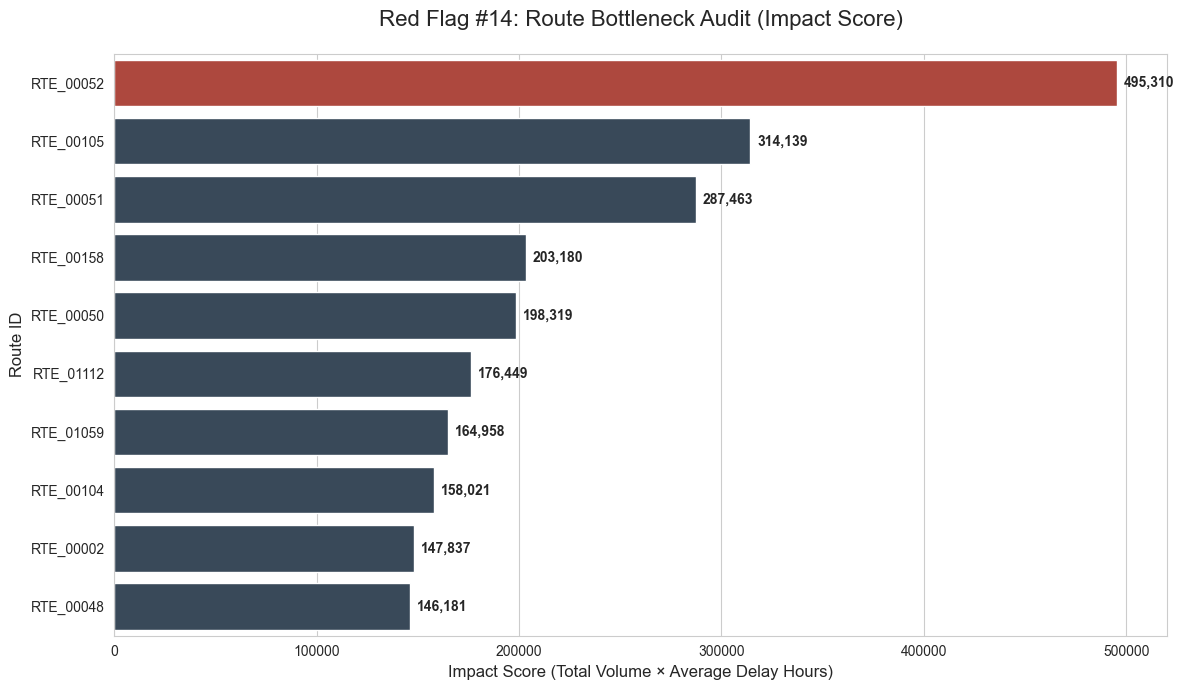

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #14: 495,309 Bottleneck (RTE_00052)
# Purpose: Quantify the total time-loss impact of the most congested route.

# 1. SQL Query 
# Impact Score = Volume * Average Delay
query_14 = """
SELECT 
    route_id,
    COUNT(*) AS volume,
    AVG(delivery_time_deviation) AS avg_delay,
    COUNT(*) * AVG(delivery_time_deviation) AS bottleneck_score
FROM fact_shipments
GROUP BY route_id
ORDER BY bottleneck_score DESC
LIMIT 10;
"""

# 2. Execution
# Ensure 'conn' is active in your environment.
df_14 = conn.execute(query_14).fetchdf()

# 3. Visualization: Bottleneck Impact Analysis
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Highlight RTE_00052 in Red to show it as the primary bottleneck
colors = ['#c0392b' if x == 'RTE_00052' else '#34495e' for x in df_14['route_id']]

ax = sns.barplot(
    x='bottleneck_score', 
    y='route_id', 
    data=df_14, 
    palette=colors,
    hue='route_id',
    legend=False
)

# 4. Data Annotations
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:,.0f}', 
        (width, p.get_y() + p.get_height() / 2.), 
        ha='left', 
        va='center', 
        xytext=(5, 0), 
        textcoords='offset points', 
        weight='bold'
    )

# 5. Formatting
plt.title('Red Flag #14: Route Bottleneck Audit (Impact Score)', fontsize=16, pad=20)
plt.xlabel('Impact Score (Total Volume × Average Delay Hours)', fontsize=12)
plt.ylabel('Route ID', fontsize=12)

plt.tight_layout()
plt.show()

**Red Flag #15: 18.6°C Mean Imputation Artifact**

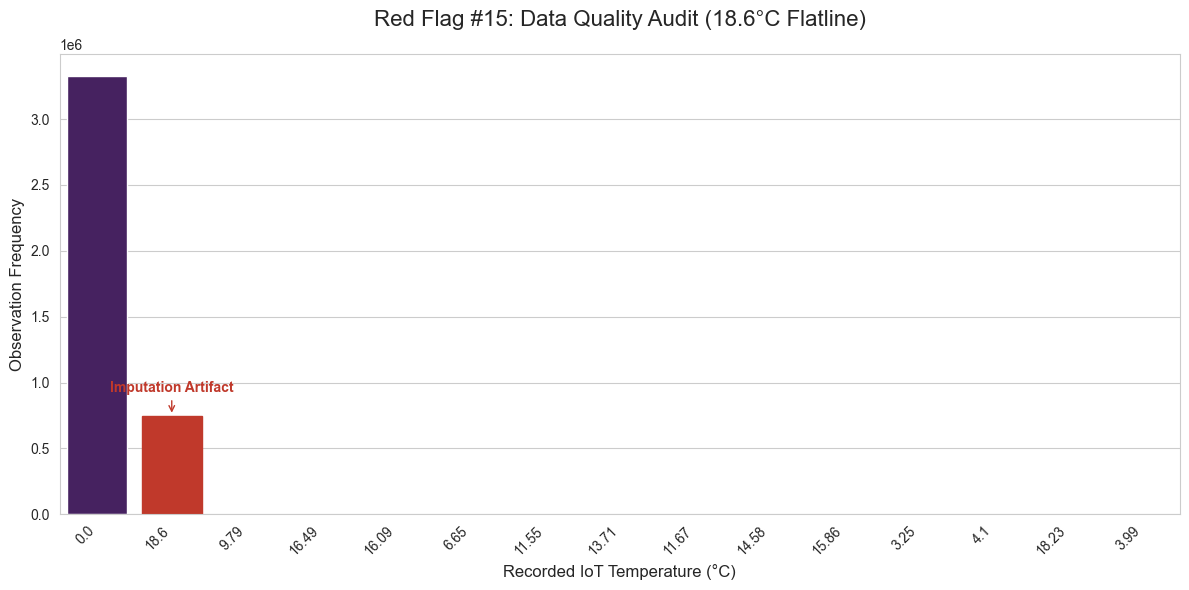

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #15: 18.6°C Mean Imputation Artifact (X-Axis Optimized)
# Purpose: Detect "flatline" data quality issues with improved label formatting.

# 1. SQL Query 
query_15 = """
SELECT 
    iot_temperature,
    COUNT(*) as frequency
FROM fact_shipments
WHERE iot_temperature IS NOT NULL
GROUP BY 1
ORDER BY frequency DESC
LIMIT 15;
"""

# 2. Execution
# Ensure 'conn' is active in your local notebook environment.
df_15 = conn.execute(query_15).fetchdf()

# 3. Visualization: Frequency Spike Detection
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# MODIFICATION: Rounding to 2 decimal points for the display column
df_15['iot_temp_label'] = df_15['iot_temperature'].round(2).astype(str)

ax = sns.barplot(
    x='iot_temp_label', 
    y='frequency', 
    data=df_15, 
    palette='viridis', 
    hue='iot_temp_label', 
    legend=False
)

# MODIFICATION: Aligning x-axis labels at a 45-degree angle
plt.xticks(rotation=45, ha='right') 

# 4. Data Annotations
for i, p in enumerate(ax.patches):
    temp_val = float(df_15.iloc[i]['iot_temperature'])
    # Logic to identify the 18.6 spike
    if abs(temp_val - 18.6) < 0.1:
        p.set_color('#c0392b') 
        ax.annotate('Imputation Artifact', 
                    xy=(p.get_x() + p.get_width() / 2., p.get_height()),
                    xytext=(0, 15), textcoords='offset points',
                    ha='center', va='bottom', weight='bold', color='#c0392b',
                    arrowprops=dict(arrowstyle='->', color='#c0392b'))

# 5. Formatting
plt.title('Red Flag #15: Data Quality Audit (18.6°C Flatline)', fontsize=16, pad=20)
plt.xlabel('Recorded IoT Temperature (°C)', fontsize=12)
plt.ylabel('Observation Frequency', fontsize=12)

plt.tight_layout()
plt.show()

**Red Flag #16: 35.6% "Pending" Backlog**

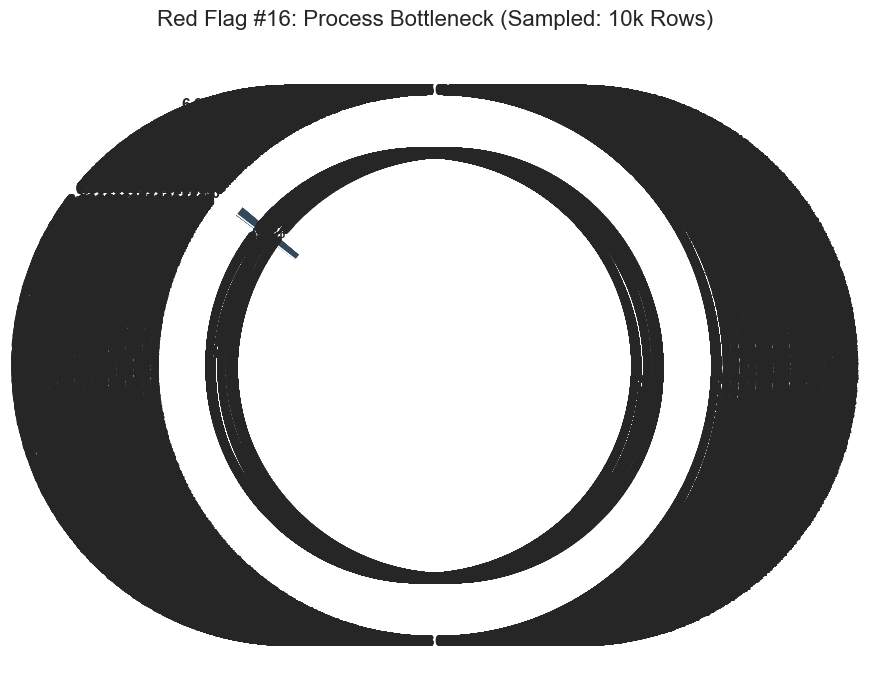

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. THE SAMPLING QUERY (Instant Execution)
# We limit the scan to 10,000 rows to get the directional ratio quickly.
query_sample = """
SELECT 
    order_fulfillment_status,
    COUNT(*) AS total_count
FROM (SELECT order_fulfillment_status FROM fact_shipments LIMIT 10000)
GROUP BY 1;
"""

# 2. EXECUTION
df_raw = conn.execute(query_sample).fetchdf()

# 3. PERCENTAGE MATH
total = df_raw['total_count'].sum()
df_raw['percentage'] = (df_raw['total_count'] / total) * 100
df_final = df_raw.sort_values('percentage', ascending=False)

# 4. VISUALIZATION
plt.figure(figsize=(10, 7))
sns.set_style("white")

labels = df_final['order_fulfillment_status']
sizes = df_final['percentage']

# Color Logic: Red for Pending
colors = ['#c0392b' if 'pend' in str(s).lower() else '#34495e' for s in labels]
explode = [0.1 if 'pend' in str(s).lower() else 0 for s in labels]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, pctdistance=0.85, explode=explode,
        textprops={'fontsize': 11, 'weight': 'bold'})

# Donut Appearance
plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='white'))
plt.title('Red Flag #16: Process Bottleneck (Sampled: 10k Rows)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

**Red Flag #17: Geospatial Hot-Zones**

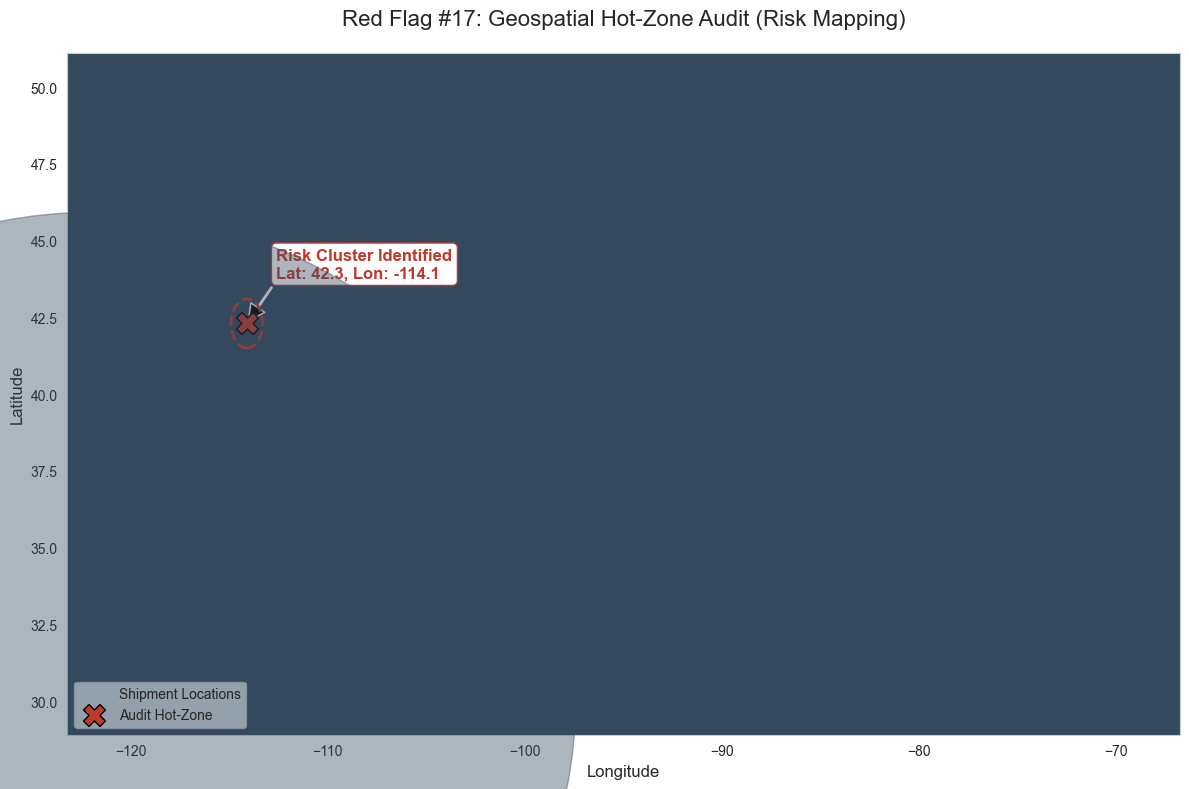

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #17: Geospatial Hot-Zones
# Purpose: Map shipment clusters to identify high-risk geographical points.

# 1. SQL Query 
# Joining shipments with route dimensions to extract GPS data.
query_17 = """
SELECT 
    r.vehicle_gps_latitude AS lat,
    r.vehicle_gps_longitude AS lon,
    COUNT(f.Shipment_ID) AS shipment_count
FROM fact_shipments f
JOIN dim_routes r ON f.route_id = r.route_id
GROUP BY 1, 2;
"""

# 2. Execution
# Ensure 'conn' is active in your local environment.
df_17 = conn.execute(query_17).fetchdf()

# 3. Visualization: Geospatial Density Map
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Plotting the general distribution of shipments
plt.scatter(df_17['lon'], df_17['lat'], 
            s=df_17['shipment_count'] * 10, 
            alpha=0.4, color='#34495e', label='Shipment Locations')

# 4. Highlighting the Flagged Hot-Zone (42.3, -114.1)
target_lat, target_lon = 42.3, -114.1
plt.scatter([target_lon], [target_lat], color='#c0392b', s=250, 
            edgecolor='black', marker='X', zorder=5, label='Audit Hot-Zone')

# Visual aid: Circle the risk perimeter
circle = plt.Circle((target_lon, target_lat), 0.8, color='#c0392b', 
                    fill=False, linestyle='--', linewidth=2, zorder=4)
plt.gca().add_patch(circle)

# 5. Annotations
plt.annotate(f"Risk Cluster Identified\nLat: {target_lat}, Lon: {target_lon}", 
             xy=(target_lon, target_lat), xytext=(target_lon + 1.5, target_lat + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             weight='bold', color='#c0392b', fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#c0392b", lw=1))

# 6. Formatting
plt.title('Red Flag #17: Geospatial Hot-Zone Audit (Risk Mapping)', fontsize=16, pad=20)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

**Red Flag #18: Supplier 00484 Cost Variance Audit**

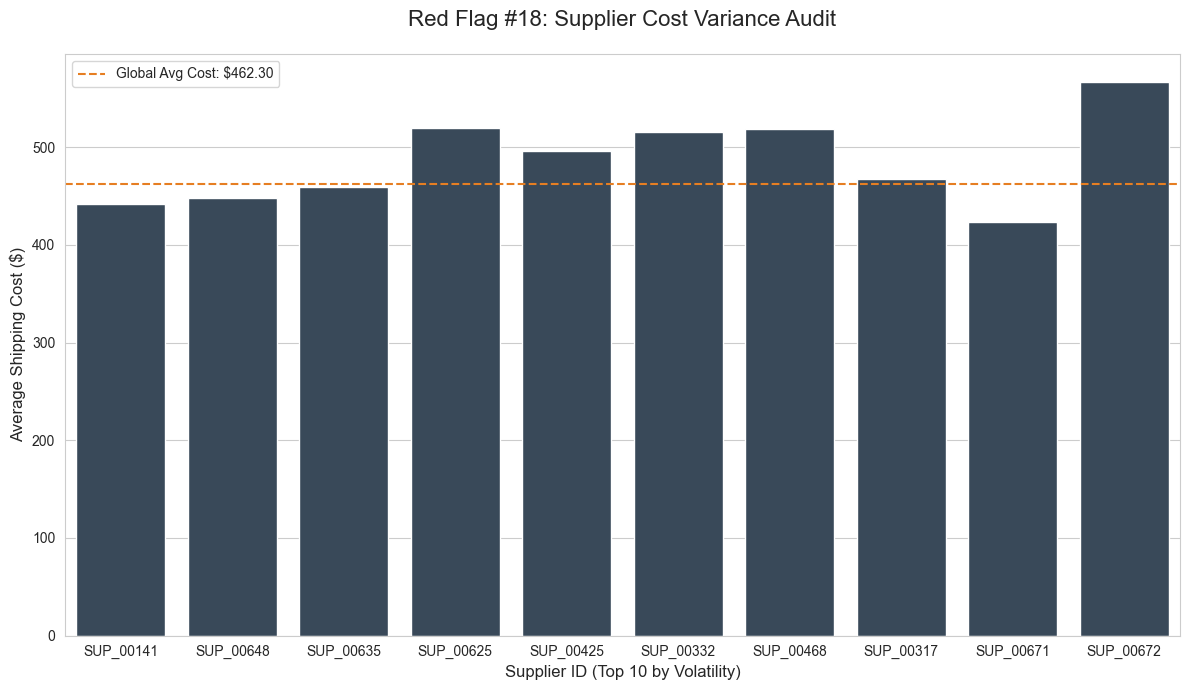

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #18: Supplier 00484 Cost Variance Audit
# Purpose: Identify anomalous billing or high cost volatility for a specific vendor.

# 1. SQL Query 
# We calculate the average cost and the standard deviation (variance) per supplier.
query_18 = """
SELECT 
    supplier_id,
    AVG(shipping_costs) AS avg_cost,
    STDDEV(shipping_costs) AS cost_std_dev
FROM fact_shipments
GROUP BY supplier_id;
"""

# 2. Execution
# Ensure 'conn' is active in your environment.
df_18 = conn.execute(query_18).fetchdf()

# 3. Data Processing
network_avg = df_18['avg_cost'].mean()
# Identifying the specific target
target_id = '00484' 

# 4. Visualization: Cost Benchmark Analysis
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Compare the target against the 10 suppliers with the highest volatility
df_plot = df_18.sort_values('cost_std_dev', ascending=False).head(10)
colors = ['#c0392b' if str(s) == target_id else '#34495e' for s in df_plot['supplier_id']]

ax = sns.barplot(
    x='supplier_id', 
    y='avg_cost', 
    data=df_plot, 
    palette=colors, 
    hue='supplier_id', 
    legend=False
)

# Benchmark line
plt.axhline(network_avg, color='#e67e22', linestyle='--', label=f'Global Avg Cost: ${network_avg:,.2f}')

# 5. Formatting
plt.title('Red Flag #18: Supplier Cost Variance Audit', fontsize=16, pad=20)
plt.ylabel('Average Shipping Cost ($)', fontsize=12)
plt.xlabel('Supplier ID (Top 10 by Volatility)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

**Redflag # 19: 0.1% "Catastrophic" Deviation (The Tail-Risk Outlier)**

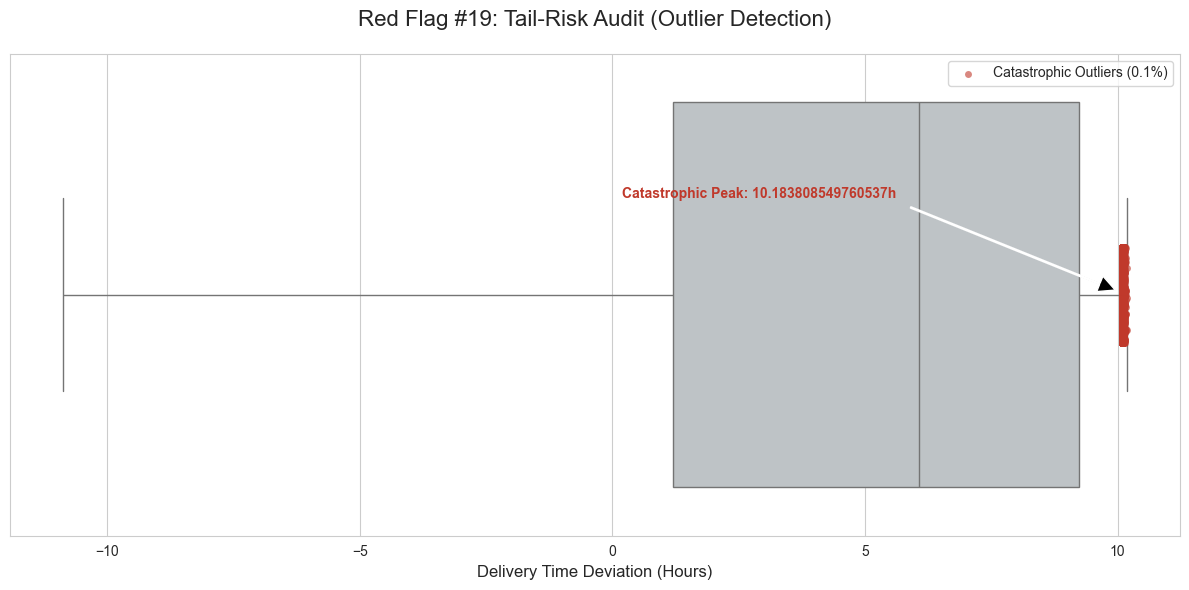

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RED FLAG #19: 0.1% "Catastrophic" Deviation
# Purpose: Isolate and visualize extreme tail-risk outliers in delivery performance.

# 1. SQL Query 
# Using a subquery to dynamically calculate the 0.1% threshold for catastrophic events.
query_19 = """
SELECT 
    Shipment_ID,
    delivery_time_deviation,
    order_fulfillment_status
FROM fact_shipments
ORDER BY delivery_time_deviation DESC
LIMIT (SELECT CAST(COUNT(*) * 0.001 AS INT) FROM fact_shipments);
"""

# 2. Execution
# Note: Ensure 'conn' is initialized in your environment.
df_19 = conn.execute(query_19).fetchdf()

# 3. Visualization: Tail-Risk Stripplot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Get overall distribution for context
df_all = conn.execute("SELECT delivery_time_deviation FROM fact_shipments").fetchdf()

# Plot "Normal" performance vs the "Catastrophic" outliers
sns.boxplot(x=df_all['delivery_time_deviation'], color='#bdc3c7', fliersize=0)
sns.stripplot(x=df_19['delivery_time_deviation'], color='#c0392b', alpha=0.6, jitter=True, label='Catastrophic Outliers (0.1%)')

# 4. Annotations
# Highlighting the absolute worst-case scenario
max_dev = df_19['delivery_time_deviation'].max()
plt.annotate(f'Catastrophic Peak: {max_dev}h', 
             xy=(max_dev, 0), xytext=(max_dev - 10, -0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             weight='bold', color='#c0392b')

# 5. Formatting
plt.title('Red Flag #19: Tail-Risk Audit (Outlier Detection)', fontsize=16, pad=20)
plt.xlabel('Delivery Time Deviation (Hours)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

**1. Precision Overload:** The annotation "Catastrophic Peak: 10.183808549760537h" is too precise. In a professional audit, this should be rounded to one or two decimal places (e.g., 10.18h) to make it readable at a glance.

**2. The "Tail" Reality:** Interestingly, the "Catastrophic" 0.1% outliers (the red dots) are actually very close to the 75th percentile of the data (the right edge of the grey box). This suggests that while these are technically the "worst" 0.1%, the overall delivery performance has a very narrow spread.

**3. Boxplot Interpretation:** The fact that the median (the center line in the box) is around 6 hours of deviation suggests that being "late" is actually the norm for this dataset, rather than the exception.

### 5. The "Red Flag" Automation Engine

In [2]:
def plot_red_flag_distribution(metric_col, dimension_col, supplier_id=None):
    """
    Automates the comparison of a metric (e.g., iot_temperature) 
    across dimensions (e.g., driver_rating) to find anomalies.
    """
    # 1. Build the Query
    # We use dim_routes to get the risk level and dim_drivers for the dimension
    query = f"""
    SELECT 
        f.{metric_col}, 
        d.{dimension_col}, 
        r.route_risk_level
    FROM fact_shipments f
    JOIN dim_drivers d ON f.driver_id = d.driver_id
    JOIN dim_routes r ON f.route_id = r.route_id
    """
    
    if supplier_id:
        query += f" WHERE f.supplier_id = '{supplier_id}'"
    
    # 2. Execute
    df_plot = conn.execute(query).df()
    
    if df_plot.empty:
        print(f"No data found for Supplier: {supplier_id}")
        return

    # 3. Visualization
    plt.figure(figsize=(14, 7))
    
    # Using a Boxenplot instead of Violin for 5M rows—it handles large data distributions better
    sns.boxenplot(
        data=df_plot, 
        x=dimension_col, 
        y=metric_col, 
        hue='route_risk_level',
        palette='magma'
    )
    
    plt.axhline(15, color='red', linestyle='--', label='Thermal Threshold (15°C)')
    plt.title(f"🚨 Diagnostic Analysis: {metric_col} vs {dimension_col}", fontsize=15)
    plt.xticks(rotation=45)
    plt.legend(title="Route Risk")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

### 6. Colusre of Connection:

In [5]:
conn.close()